# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

- Автор: Федоров Алексей Анатольевич
- Дата: 15.06.2026

<a id='цели-и-задачи-проекта'></a>
### Цели и задачи проекта

Построение модели на основе логистической регрессии для прогнозирования вероятности оттока каждого клиента в следующем месяце для сервиса доставки кофе на основе датасета **coffee_churn_dataset.csv**.

1. **Цель:** по признакам датасета найти вероятность положительного события churn = 1 для каждого клиента в следующем месяце, чтобы эффективно спланировать по этим данным акции по удержанию клиентов.

2. **Целевая переменная**: `churn`.

3. **Метрики качества модели**:
    группы клиентов с churn=0 и churn=1 несбалансированные, поэтому:
   - **Основная**: PR AUC (площадь под кривой PR);
   - **Дополнительные**: F1-score (гармоническое среднее), Recall, Precision.

4. **Требования к модели**:
   ориентировочные параметры качества модели, чтобы исключить ложные срабатывания по Precision и получить хороший охват клиентов, которые покинут компанию в следующем месяце Recall:
   - **PR_AUC >= 0.7 - важно**;
   - **Recall >= 0.8 - второстепенно, но желательно** (найти 60 - 70% уходящих);
   - **Precision >= 0.8 - важно** (80% найденных клиентов действительной уйдут: чтобы повысить, поднять порог классификации);
   - **F1 >= ??**.

<a id='описание-данных'></a>
### Описание данных
Датасет coffee_churn_dataset.csv собран за последние 4 недели, на каждого клиента 1 строка.

- **`user_id`** — идентификатор пользователя
- **`days_since_last_order`** — количество дней, прошедших с последнего заказа
- **`order_frequency_month`** — среднее число заказов в месяц
- **`order_frequency_week`** — среднее число заказов в неделю
- **`avg_order_value`** — средний чек, в рублях
- **`median_order_value`** — медианный чек, в рублях
- **`total_spent_last_month`** — сумма заказов за последний месяц
- **`total_spent_last_week`** — сумма заказов за последнюю неделю
- **`discount_usage_rate`** — доля заказов со скидкой за последний месяц
- **`last_coffee_type`** — сорт кофе, купленный пользователем в последний раз на момент сбора данных
- **`preferred_roast`** — предпочитаемый тип обжарки
- **`milk_preference`** — предпочитаемый тип молока
- **`seasonal_menu_tried`** — отметка о том, пробовал ли пользователь новейшее сезонное меню
- **`coffee_bean_origin`** — страна происхождения зерна
- **`last_drink_size`** — размер последнего заказа, совершённого на момент сбора данных
- **`subscription_status`** — тип подписки пользователя
- **`app_opens_per_week`** — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе
- **`notifications_enabled`** — включены ли у пользователя уведомления
- **`review_rating_last_10`** — средняя оценка последних на момент сбора данных десяти заказов клиента
- **`review_rating_last_1`** — оценка последнего на момент сбора данных заказа клиента
- **`app_crashes_last_month`** — сколько раз приложение зависало за последний месяц
- **`seasons`** — текущее время года
- **`days_since_last_promo`** — сколько дней прошло с последнего использования акции или промокода
- **`phone_type`** — тип устройства, с которого пользователь чаще всего совершал покупки
- **`coffee_preference_change`** — менялись ли вкусовые предпочтения пользователя
- **`geo_id`** — идентификатор региона пользователя
- **`churn`** — перестал ли пользователь пользоваться сервисом

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

<a id='подключение-и-настройка-библиотек'></a>
### Подключение и настройка библиотек

In [1]:
dependences = (
    "install",
    "numba==0.58.1", # надо для scikit-learn 1.6.1 и pandas
    "numpy==1.25.2",
    "pandas==2.1.4",
    "jinja2>=3.1.2",
    "phik==0.12.5",
    "seaborn==0.13.0",
    "statsmodels==0.14.1",
    "matplotlib==3.8.2",
    "scikit-learn==1.6.1",
)

In [2]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", *dependences])

  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.1
    Uninstalling numpy-1.21.1:
      Successfully uninstalled numpy-1.21.1
  Attempting uninstall: python-dateutil
    Found existing installation: python-dateutil 2.8.1
    Uninstalling python-dateutil-2.8.1:
      Successfully uninstalled python-dateutil-2.8.1
  Attempting uninstall: scipy
    Found existing installation: scipy 1.9.1
    Uninstalling scipy-1.9.1:
      Successfully uninstalled scipy-1.9.1
  Attempting uninstall: patsy
    Found existing installation: patsy 0.5.2
    Uninstalling patsy-0.5.2:
      Successfully uninstalled patsy-0.5.2
  Attempting uninstall: pandas
    Found existing installation: pandas 1.2.4
    Uninstalling pandas-1.2.4:
      Successfully uninstalled pandas-1.2.4
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.3.4
    Uninstalling matplotlib-3.3.4:
      Successfully uninstalled matplotlib-3.3.4
  Attempting uninstall: llvmlite
    Found ex

0

In [74]:
import calendar
import gc
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import time
from dataclasses import dataclass
from IPython.display import Markdown, HTML, display_html
import joblib
from joblib import Memory
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import phik
from phik import phik_matrix
import seaborn as sns
import sklearn
from sklearn.utils.validation import check_is_fitted
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import IterativeImputer
from sklearn.linear_model import (
    Lasso, LinearRegression, LogisticRegression, Ridge, SGDRegressor,
)
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    fbeta_score,
    make_scorer,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    PredefinedSplit,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    MinMaxScaler,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
    TargetEncoder,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from tqdm.auto import tqdm

<a id='версии-библиотек'></a>
### Версии библиотек

In [4]:
print(
    f"Путь к Python: {sys.executable}",
    f"Версия Python: {sys.version}",
    f"Текущий путь: {os.getcwd()}",
    f"pandas: {pd.__version__}",
    f"numpy: {np.__version__}"
    f"\n\tБэкенд pandas (plotting): {pd.options.plotting.backend}",
    f"phik: {phik.__version__}",
    f"matplotlib: {matplotlib.__version__}",
    f"seaborn: {sns.__version__}",
    f"sklearn: {sklearn.__version__}",
sep='\n')

Путь к Python: /opt/conda/bin/python
Версия Python: 3.9.5 | packaged by conda-forge | (default, Jun 19 2021, 00:32:32) 
[GCC 9.3.0]
Текущий путь: /home/jovyan/work
pandas: 2.1.4
numpy: 1.25.2
	Бэкенд pandas (plotting): matplotlib
phik: 0.12.5
matplotlib: 3.8.2
seaborn: 0.13.0
sklearn: 1.6.1


<a id='константы'></a>
### Константы

In [5]:
DATASETS_BASE = 'https://code.s3.yandex.net/datasets'
LOCAL_DATA_FILE_PATH = '/datasets/coffee_churn_dataset.csv'
S3_DATA_FILE_PATH = f'{DATASETS_BASE}/coffee_churn_dataset.csv'
SEED = 42
TARGET = 'churn'

In [6]:
memory = Memory(location='./cache_pipeline', verbose=0)

<a id='общие-функции'></a>
### Общие функции

<a id='базовые'></a>
#### Базовые

In [7]:
def show_ds_short_info(df):
    """
        Выводит информацию о размерности датасета и перечень колонок.
    """
    print(
        f'\tВсего: {df.shape[0]} строк, {df.shape[1]} колонок',
        f'\tКолонки датасета: {df.columns.tolist()}\n', sep='\n')
    
def show_item(num, name, action):
    """
        Отображает любой шаг анализа, заданный через func, в виде блока с заголовком.
    """
    print(f'{num}. {name}', '=' * 20)
    action()    
    
def show(start_num, *name_action):
    """
        Отображает шаги анализа с заголовком, нумерацией и разделением.
        Стартовая нумерация задайтся в start_num.
        Шаги переаются списком аргументов переменной длины: name, action. 
    """
    if len(name_action) % 2:
        raise ValueError('Нечётное число аргументов. В show передавайте пары значений name, action как единый список аргументов.')
    
    num_args = len(name_action)
    num = start_num
    
    for i in range(0, num_args, 2):
        if i != 0:
            print('\n')
        show_item(num, name_action[i], name_action[i + 1])
        num += 1
        if i < i - 2:
            print('\n')

def report_row_removing(before, after):
    print(f'✅ Из датасета в {before} строк удалено 🗑️ {before - after} строк,\n'
        f'\tосталось: {after} строк,\n'
        f'\tпроцент потерь: {round((before - after) / before * 100, 2)}%.')
            
def downcast_columns(data_frame, *, ints = None, floats = None):
    """
    Приводит колонки к оптимальным nullable-типам pandas с downcast.

    - Integer колонки: Int64 -> Int8/16/32 в зависимости от диапазона значений.
    - Float колонки: Float64 -> Float32.
    - Object колонки: object -> string.

    Parameters
    ----------
    data_frame : pd.DataFrame
        DataFrame для оптимизации. Изменяется на месте.

    Returns
    -------
    pd.DataFrame
        Тот же объект с оптимизированными типами.
    """
    
    ints_actual = set(ints or []) | set(data_frame.select_dtypes(include="integer").columns)
    floats_actual = set(floats or []) | set(data_frame.select_dtypes(include="float").columns) - ints_actual
    
    for col in ints_actual:
        data_frame[col] = pd.to_numeric(data_frame[col], errors='coerce')
        col_min, col_max = data_frame[col].min(), data_frame[col].max()
        
        if col_min >= -128 and col_max <= 127:
            data_frame[col] = data_frame[col].astype('Int8')
        elif col_min >= -32768 and col_max <= 32767:
            data_frame[col] = data_frame[col].astype('Int16')
        elif col_min >= -2147483648 and col_max <= 2147483647:
            data_frame[col] = data_frame[col].astype('Int32')
        else:
            data_frame[col] = data_frame[col].astype('Int64')

    for col in floats_actual:
        data_frame[col] = pd.to_numeric(data_frame[col], errors='coerce')
        data_frame[col] = data_frame[col].astype('Float32')

    for col in data_frame.select_dtypes(include="object"):
        data_frame[col] = data_frame[col].astype('string')

    return data_frame

def downcast_columns_for_ml(data_frame, *, ints=None, floats=None, cats=None):
    """Приводит колонки к оптимальным NumPy-типам для ML с downcast.

    - Integer колонки: int64 -> int8/16/32/64 в зависимости от диапазона.
    - Float колонки: float64 -> float32.
    - Object/String колонки: object -> category (для экономии памяти и ML).

    ВАЖНО: В отличие от Extended-типов pandas, стандартные целочисленные типы
    NumPy (int8-int64) НЕ поддерживают NaN. Если в целочисленной колонке есть
    пропуски, pandas принудительно оставит её в типе float32/64.
    """

    ints_actual = set(ints or []) | set(
        data_frame.select_dtypes(include="integer").columns
    )
    floats_actual = (
        set(floats or [])
        | set(data_frame.select_dtypes(include="float").columns)
    ) - ints_actual
    cats_actual = set(cats or []) | set(
        data_frame.select_dtypes(include=["object", "string"]).columns
    )

    for col in ints_actual:
        # Приводим к числовому типу NumPy
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")

        # Если в колонке есть NaN, NumPy int не сможет её сохранить.
        # В таком случае переводим её во float32, чтобы не ломать ML-алгоритмы.
        if data_frame[col].isnull().any():
            data_frame[col] = data_frame[col].astype(np.float32)
            continue

        col_min, col_max = data_frame[col].min(), data_frame[col].max()

        if col_min >= -128 and col_max <= 127:
            data_frame[col] = data_frame[col].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            data_frame[col] = data_frame[col].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            data_frame[col] = data_frame[col].astype(np.int32)
        else:
            data_frame[col] = data_frame[col].astype(np.int64)

    for col in floats_actual:
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")
        data_frame[col] = data_frame[col].astype(np.float32)

    # Для ML текстовые признаки переводим в категориальный тип, а не в string
    for col in cats_actual:
        data_frame[col] = data_frame[col].astype("category")

    return data_frame


<a id='базовый-eda'></a>
#### Базовый EDA

In [8]:
def get_missing_values_statistics(df, name=None):
    """
        Проверяет все колонки DataFrame df на пропуски: np.nan, None, pd.NA.
        Возвращает DataFrame, содержащий две колоки: число пропусков и % пропусков по мнению функции isna( ).        
        В качестве индекса выступают имена колонок. Возвращаются только строки с ненулевыми данными.
    """
    subject = df if name is None else df[name]
    missing_count_seria = subject.isna().sum().loc[lambda v: v > 0].sort_values(ascending=False)
    missing_fraction = round(missing_count_seria / df.shape[0] * 100, 2)
    result = pd.DataFrame(
        {'Пропущено (np.nan, None, pd.NA)': missing_count_seria, 'Доля пропусков %': missing_fraction}
    )
    
    return 'В колонках DataFrame нет пропусков' if result.empty else result

def normalize_text_cols(df, *col_names, to_lower=True):
    """
        Конвертирует колонки col_names в string, обрезает пробелы с концов и нормализует пробелы внутри строк.
        Если задано to_lower, то приводит к нижнему регистру.
    """
    for name in col_names:        
        df[name] = df[name].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
        if to_lower:
            df[name] = df[name].str.lower()

def get_reference_info(df, name, numeric=False, limit = 50):
    """
        Выполняет проверку серии name из DataFrame df как категории. А именно:
            - выводит TOP 50 уникальных значений серии и общее число уникальных значений;
            - выводит счётчик встречаемости и % для каждого значения в серии name;
            - если серия числовая, то ещё выводит min и max значения.
        Таким образом, помогает оценить качество справочника или просто серии (колонки) и заметить неявные дубликаты.
    """
    values = df[name].drop_duplicates().sort_values()
    len_values = len(values)
    lst = values.head(limit).to_list()
    
    elipsis = ', ...' if len_values > limit else ''
    display(Markdown(f"**{name}:** `{lst}{elipsis}` = **{len_values}**\n\n"))
        
    counts_df = df[name].value_counts(dropna=False).astype('float64').to_frame('count')
    counts_df.index = counts_df.index.map(lambda x: '<NA>' if pd.isna(x) else x)
    counts_df['%'] = (counts_df['count'] / counts_df['count'].sum() * 100).round(2)        
    counts_df['count'] = counts_df['count'].astype('Int64')
             
    display(counts_df)
            
    print('\nПропущено:', df[name].isna().sum())
    
    if numeric:
        values_num = pd.to_numeric(df[name], errors='coerce')        
        min_val = values_num.min()
        max_val = values_num.max()
        print(f'min = {min_val}, mean = {round(values_num.mean(), 2)}, max = {max_val}, median = {values_num.median()}')
                
        whisker_left, whisker_right = get_whiskers(values_num, left=min_val, right=max_val)
        print(f'left_whisker = {whisker_left}, right_whisker = {whisker_right}')

        non_numeric = values[values_num.isna()].tolist()
        if non_numeric:
            print(f'Нецифровые значения: {non_numeric}')
    print('\n')
    
def get_frequency_report(df, name):
    """
        Возвращает частотный отчёт по колонке данных: все характеристики повторяемости значений в разных строках.
    """
    counts = df[name].value_counts(dropna=False)
    return pd.Series({
        'Среднее': counts.mean(),
        'Медиана': counts.median(), 
        'Мода': counts.mode().iloc[0] if len(counts.mode()) > 0 else None,
        'Макс': counts.max(),
        'Мин': counts.min()
    }), counts

def fill_missing(df, col, na_cat='unknown', implicit_na=('none', 'na', '-', 'nan')):
    if na_cat not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories(na_cat)

    for label in implicit_na:
        if label in df[col].cat.categories:
            df[col] = df[col].replace(label, na_cat)
        
        df[col] = df[col].fillna(na_cat)
        
        if label in df[col].cat.categories:
            df[col] = df[col].cat.remove_categories(label)
            
    if len(df[df[col] == na_cat]) == 0:
        df[col] = df[col].cat.remove_categories(na_cat)


<a id='статистический-анализ'></a>
#### Статистический анализ

In [9]:
def get_whiskers(values, coeff=1.5, left=None, right=None):
    """
        Возвращает усы ящика для серии values.
    """
    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1
    
    w_left = Q1 - coeff * IQR
    w_right = Q3 + coeff * IQR
    
    if left is not None:
        w_left = max(left, w_left)
    if right is not None:
        w_right = min(right, w_right)
        
    return w_left, w_right

    
def test_normal_distribution(df, name):
    """
    Проверяет колонку name на соотвествие Нормальному распределению (близость к нему).
    """
    skewness = df[name].skew()
    kurtosis = df[name].kurt()

    # Проверка правилом "одной сигмы" (должно быть ~68.27%)
    avg = df[name].mean()
    std = df[name].std()

    within_1_sigma = df[name].between(avg - std, avg + std).mean()

    print(f"Коэффициент асимметрии: {skewness:.3f} (норма ~ 0)")
    print(f"Коэффициент эксцесса: {kurtosis:.3f} (норма ~ 0)")
    print(f"Доля данных в пределах 1 сигмы: {within_1_sigma:.2%} (норма ~ 68.3%)")

    # Интерпретация
    if abs(skewness) < 0.5 and within_1_sigma > 0.65:
        print("\nВывод: Распределение близко к нормальному.\n")
    else:
        print("\nВывод: Есть значительные отклонения от нормальности.\n")      
        
def check_vif(df, fields, top=10):
    """Расчет фактора инфляции дисперсии (VIF) для проверки мультиколлинеарности.

    Интерпретация значений VIF:
    - VIF = 1: коллинеарность отсутствует.
    - 1 < VIF <= 5: умеренная коллинеарность (допустимо).
    - VIF > 10: критический уровень, признак рекомендуется удалить.

    Важно: функция удаляет строки с пропусками (dropna).
    """
    df_vif = df[list(fields)].astype(float).dropna()

    df_with_const = add_constant(df_vif)

    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_vif.columns

    vif_data["VIF"] = [
        variance_inflation_factor(
            df_with_const.values, df_with_const.columns.get_loc(col)
        )
        for col in df_vif.columns
    ]

    return vif_data.sort_values(by="VIF", ascending=False).head(top)

<a id='графика'></a>
#### Графика

In [10]:
def show_phik_corr(phik_matrix, target_col, name, width = 13):
    order_corr_seg = (
        phik_matrix[[target_col]]
        .drop(index=[target_col], errors='ignore') # Удаляем связь с самим собой
        .sort_values(by=target_col, ascending=False)
        .T
    )

    plt.figure(figsize=(width, 4))

    sns.heatmap(
        order_corr_seg, 
        annot=True, 
        fmt=".2f", 
        cmap='YlOrRd', 
        linewidths=1.5,
        cbar=False
    )

    plt.title(name, fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=20, ha='right')
    plt.yticks([]) 

    plt.tight_layout()
    plt.show()

def show_linear_dep(df, fields): 
    """Строит матрицу графиков рассеяния с линиями регрессии для поиска мультиколлинеарности.

    Включает автоматическое приведение к float, удаление NaN и случайное
    семплирование до 2000 строк для оптимизации отрисовки.

    Args:
        df (pd.DataFrame): Исходный датафрейм.
        fields (list): Список названий целевых числовых столбцов.

    Returns:
        None: Отображает график через plt.show().
    """
    df_numeric = df[fields].astype(float).dropna()

    sns.set_context("paper", font_scale=1.2)

    g = sns.pairplot(
        df_numeric.sample(min(2000, len(df_numeric))), 
        kind='reg',        # Добавляет линию регрессии на каждый график
        diag_kind='kde',   # На диагонали оставляем распределения
        height=3, 
        aspect=1.2,
        plot_kws={
            'line_kws': {'color': 'darkred'}, # Цвет линий
            'x_jitter': 0.2,
            'scatter_kws': {'alpha': 0.3, 'color': 'salmon', 's': 20} # Цвет и прозрачность точек
        }
    )

    # У pairplot ЕСТЬ атрибут .fig, поэтому тут это сработает
    g.fig.suptitle('Матрица линейных зависимостей интервальных признаков', y=1.02, fontsize=16, fontweight='bold')

    plt.show()

def show_corr_heatmap(df, fields, target_field, method='pearson'):
    all_fields = list(set(list(fields) + [target_field]))

    df_corr = df[all_fields].astype(float)

    corr_matrix = df_corr.corr(method=method)

    sorted_fields = corr_matrix[target_field].sort_values(ascending=False).index
    corr_matrix = corr_matrix.loc[sorted_fields, sorted_fields]

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        annot_kws={"size": 11},
    )

    plt.title(
        f"Матрица корреляции Пирсона (по: {target_field})",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()
    plt.show()
    
def plot_boxes(df, columns, title, axis_name, orient='v', figsize=(14, 6)):            
    plt.figure(figsize=figsize)

    # Приводим к float для корректной обработки nullable Int16
    df_plot = df[list(columns)].astype(float)
    
    ax = sns.boxplot(data=df_plot, orient=orient)
    
    data_min = float(df_plot.min().min())
    data_max = float(df_plot.max().max())

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    
    if orient == "v":
        plt.xticks(rotation=45, ha="right", fontsize=14)
        ax.set_ylabel(axis_name, fontsize=14)

        # Получаем стандартные метки, которые matplotlib построил для оси Y
        current_ticks = ax.get_yticks()
        # Фильтруем те, что выходят за реальные границы данных
        current_ticks = [t for t in current_ticks if data_min <= t <= data_max]
        # Добавляем точный min и max, убираем дубликаты и сортируем
        new_ticks = sorted(list(set(current_ticks + [data_min, data_max])))

        # Применяем новые метки на ось Y
        ax.set_yticks(new_ticks)
        plt.yticks(fontsize=14)
        plt.grid(axis="y", linestyle="--", alpha=0.5)
    else:
        ax.set_xlabel(axis_name, fontsize=14)
        plt.yticks(fontsize=14)

        # Получаем стандартные метки, которые matplotlib построил для оси X
        current_ticks = ax.get_xticks()
        current_ticks = [t for t in current_ticks if data_min <= t <= data_max]
        new_ticks = sorted(list(set(current_ticks + [data_min, data_max])))

        # Применяем новые метки на ось X
        ax.set_xticks(new_ticks)
        plt.xticks(fontsize=14)
        plt.grid(axis="x", linestyle="--", alpha=0.5)
        
        plt.gcf().canvas.draw()

        # Получаем список всех текстовых объектов меток оси X
        labels = ax.get_xticklabels()

        if len(labels) >= 2:
            custom_pad = -0.05
            # Поворачиваем первую метку (минимум)
            labels[0].set_rotation(90)
            labels[0].set_transform(labels[0].get_transform())
            labels[0].set_ha("right")
            labels[0].set_y(custom_pad)

            # Поворачиваем последнюю метку (максимум)
            labels[-1].set_rotation(90)
            labels[-1].set_transform(labels[-1].get_transform())
            labels[-1].set_ha("right")
            labels[-1].set_y(custom_pad)
        
    plt.tight_layout()
    plt.show()
    
def show_full_phik_heatmap(
    df, fields, target_field, continuous_fields, figsize=(16, 14), cbar=False
):
    """Рассчитывает полную матрицу Phik для всех типов признаков."""
    all_fields = list(set(list(fields) + [target_field]))
    df_sub = df[all_fields].copy()

    print("Рассчитываю матрицу Phik...")
    phik_corr = df_sub.phik_matrix(interval_cols=continuous_fields)

    # сортируем по силе связи с целевой переменной
    sorted_fields = phik_corr[target_field].sort_values(ascending=False).index
    phik_corr = phik_corr.loc[sorted_fields, sorted_fields]

    # тепловая карта
    plt.figure(figsize=figsize)
    sns.heatmap(
        phik_corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        # цветовая шкала
        cbar=cbar,
        annot_kws={
            "size": 9
        },  # Чуть уменьшили цифры внутри ячеек, чтобы они не слипались
    )

    plt.title(
        f"Полная матрица корреляции Phik (отсортирована по: {target_field})",
        fontsize=18,
        fontweight="bold",
        pad=20,
    )

    # УВЕЛИЧИЛИ ШРИФТ НАЗВАНИЙ ПЕРЕМЕННЫХ:
    plt.xticks(
        rotation=45, ha="right", fontsize=13
    )  # Шрифт по оси X (горизонтальная)
    plt.yticks(fontsize=13)  # Шрифт по оси Y (вертикальная)

    plt.tight_layout()
    plt.show()
    
    return phik_corr

<a id='обучение'></a>
#### Обучение

In [11]:
def separate_target(target, *data_frames):
    """
    Разделяет каждый DataFrame на.features (X) и целевую переменную (y).

    Args:
        target: имя целевой колонки.
        *data_frames: произвольное число DataFrame для разделения.

    Returns:
        Кортеж (X1, y1, X2, y2, ..., Xn, yn), где для каждого входного DataFrame
        X = df.drop(columns=[target]), y = df[target].
    """
        
    def sep(df):        
        return df.drop(columns=[target]), df[target]
    
    result = []
    for df in data_frames:
        X, y = sep(df)
        result.extend([X, y.astype('float64').to_numpy()])  
        
    return tuple(result)

def get_model_metrics(model, X, y):
    pred = model.predict(X)
    return {
        "MAE":  mean_absolute_error(y, pred),
        "MSE":  mean_squared_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2":   r2_score(y, pred),
        "MAPE": mean_absolute_percentage_error(y, pred),
    }

def show_metrics_cross_table(df, metrics):
    # Строим кросс-таблицу: модели × масштабирование
    pivot_mae = df.pivot(index="model", columns="scaling", values=metrics)    

    # Округляем числа из PIVOT_MAE (здесь только числа, без текста!)
    rounded_vals = np.round(pivot_mae.to_numpy().flatten(), 5)
    unique_vals = np.unique(rounded_vals)

    # Инвертируем ранги: меньшее число (лучшее) получает ранг 1.0
    max_idx = len(unique_vals) - 1 if len(unique_vals) > 1 else 1
    val_to_rank = {val: 1.0 - (idx / max_idx) for idx, val in enumerate(unique_vals)}

    # Создаем БЛЕДНУЮ пастельную палитру:
    # 0.0 (худший) -> приглушенный серый/коричневый
    # 1.0 (лучший) -> пастельно-зеленый
    cmap = mcolors.LinearSegmentedColormap.from_list("pale_mae", ["#e6dfda", "#a1dbb2"])

    # Функция окрашивания ячеек
    def color_by_exact_value(sub_df):
        return sub_df.applymap(lambda val: f"background-color: {mcolors.to_hex(cmap(val_to_rank[np.round(val, 5)]))}")
    
    display(
        pivot_mae.style.format("{:.5f}")
        .apply(color_by_exact_value, axis=None)
    )

def show_metrics(df, metrics):
    # Сортируем датафрейм по возрастанию MAE
    sorted_df = df.sort_values(metrics).reset_index(drop=True)

    def smart_numeric_format(val):
        if not isinstance(val, (int, float, np.number)):
            return val

        # Если число гигантское (больше миллиона) или микроскопическое (меньше 0.0001)
        if abs(val) > 1e6 or (0 < abs(val) < 1e-4):
            return f"{val:.5e}" 

        # Для обычных чисел — честные 5 знаков после запятой
        return f"{val:.5f}"


    display(
        sorted_df
        .style.format(smart_numeric_format)    
    )

class LinearModelPredictor:
    def __init__(self, model_pipeline):
        self.transform_pipeline = Pipeline([s for s in model_pipeline.steps if s[0] != "model"])
        model = model_pipeline.named_steps["model"]
        self.coef = model.coef_
        self.intercept = model.intercept_
        
    def predict(self, df_X_values):
        X = self.transform_pipeline.transform(df_X_values)
        X = np.asarray(X, dtype='float64')
        
        return X @ self.coef + self.intercept

<a id='загрузка-датасета'></a>
### Загрузка датасета

In [12]:
data_path = LOCAL_DATA_FILE_PATH if os.path.exists(LOCAL_DATA_FILE_PATH) else S3_DATA_FILE_PATH
df = pd.read_csv(data_path, decimal='.', sep=',', skipinitialspace=True)

In [13]:
df_shape = df.shape
print(f'✅ Датасет загружен с "{data_path}" содержит: {df_shape[0]} строк')

✅ Датасет загружен с "/datasets/coffee_churn_dataset.csv" содержит: 10450 строк


## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

### Ознакомление с данными

In [14]:
show(1, 
     'Датасет "turtles"', lambda: show_ds_short_info(df),
     'info', lambda: df.info(),     
)

1. Датасет "turtles" ====================
	Всего: 10450 строк, 27 колонок
	Колонки датасета: ['user_id', 'days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'seasons', 'days_since_last_promo', 'phone_type', 'coffee_preference_change', 'geo_location', 'churn']



2. info ====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order    

👉 Колонки почти совпадают с описанием, они в Snake Case, за исключением **geo_location**, в описании она называется **geo_id**. Исправим это.

In [15]:
df = df.rename(columns={'geo_location': 'geo_id'})

✅ Исправили geo_location.
👉 Добавить проверку имени поля в трансформер, чтобы работало на проде.

In [16]:
show(3,      
     'Пропуски данных по колонкам', lambda: display(get_missing_values_statistics(df)),
     'Пример данных', lambda: display(df),
)

3. Пропуски данных по колонкам ====================


,"Пропущено (np.nan, None, pd.NA)",Доля пропусков %
seasonal_menu_tried,989,9.46
days_since_last_order,945,9.04
total_spent_last_week,944,9.03
subscription_status,938,8.98
app_opens_per_week,896,8.57
review_rating_last_1,857,8.20
median_order_value,831,7.95
days_since_last_promo,731,7.00
app_crashes_last_month,721,6.90
review_rating_last_10,693,6.63




4. Пример данных ====================


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_id,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10445,user_05734,5.0,NaN,0.807372,288.187339,NaN,465.497296,82.772110,0.285469,arabica,...,1.0,3.149287,5.180760,NaN,summer,2.0,android,NaN,NaN,0
10446,user_05191,NaN,8.265273,1.942752,1151.879696,392.095861,3323.512340,535.414300,0.172886,blend,...,1.0,5.144074,2.438754,NaN,winter,17.0,ios,1.0,geo_36,0
10447,user_05390,0.0,4.303173,1.029802,1303.253909,477.969319,1854.476109,551.436986,0.502961,arabica,...,1.0,3.975122,5.018790,1.0,winter,7.0,ios,0.0,geo_12,0
10448,user_00860,7.0,1.964595,0.350771,965.339923,465.489241,833.596910,203.599663,0.137200,arabica,...,0.0,4.564480,2.024267,1.0,autumn,NaN,ios,0.0,geo_3,0


Всего **10 450 строк, 27 колонок**. Данные загрузились корректно. В целевой переменной пропусков нет, во многих остальных признках пропуски **<5%** (незначительные), либо **<10%** (умеренные). Когда выберем колонки, нужные для обучения модели, то можно будет выбрать признаки с пропусками для удаления строк или для заполнения. Сделаем при детальном анализе.

### Типы данных, их оптимизация

Есть ряд пропусков в текстовых признаках, поэтому загрузились типы object, их преобразуем в string и сразу нормализуем пробелы и приведём к нижнему регистру.

In [17]:
normalize_text_cols(df, *df.select_dtypes(include=['object']).columns.tolist())

In [18]:
string_df = df.select_dtypes(include=["string"])

if not string_df.empty:
    display(string_df.describe())
else:
    print("Колонки с типом 'string' не найдены.")

,user_id,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type,geo_id
count,10450,10192,10334,9782,9768,9946,9512,9771,10114,10340
unique,10450,3,3,6,6,3,4,4,3,100
top,user_00967,arabica,medium,whole,ethiopia,medium,none,spring,android,geo_2
freq,1,6134,3458,2876,1690,4925,3803,2507,4611,1629


✅ После преобразования object к string и нормализации строк, стало видно, что **user_id** корректен, он уникальный и без пропусков. Остальные строковые признаки представляют из себя категории с небольшим количеством уникальных значений. Исключение составляет **geo_id**: это очень большая категория на 100 значений.

А теперь оптимизируем типы даных под ML и по размеру памяти: подберём оптимальные типы NumPy, а string заменим на category. Категориальный тип значительно экономит память, так как основан на словаре. Кроме того, некоторые модели ML умеют работать с category без кодирования, за счёт включения enable_categorical=True. Поэтому, category вдвойне полезный тип, который предпочтительнее, чем string.

In [19]:
int_cols = (
    'days_since_last_order',
    'seasonal_menu_tried',
    'notifications_enabled',
    'app_crashes_last_month',
    'days_since_last_promo',
    'coffee_preference_change',
    'churn'
)
downcast_columns_for_ml(df, ints=int_cols);

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   user_id                   10450 non-null  category
 1   days_since_last_order     9505 non-null   float32 
 2   order_frequency_month     9850 non-null   float32 
 3   order_frequency_week      10062 non-null  float32 
 4   avg_order_value           9867 non-null   float32 
 5   median_order_value        9619 non-null   float32 
 6   total_spent_last_month    10156 non-null  float32 
 7   total_spent_last_week     9506 non-null   float32 
 8   discount_usage_rate       10053 non-null  float32 
 9   last_coffee_type          10192 non-null  category
 10  preferred_roast           10334 non-null  category
 11  milk_preference           9782 non-null   category
 12  seasonal_menu_tried       9461 non-null   float32 
 13  coffee_bean_origin        9768 non-null   cate

✅ Оптимизировали типы данных, используя типы NumPy: объём памяти снизился с 2.2 Mb до 1.1 Mb: На **50%**.

### Дубликаты

Теперь проверимм на явные дубликаты. user_id уже проверили выше, он уникален. Осталось проверить дублирование строк по оставшимся полям.

In [21]:
cols_to_check = df.columns.drop("user_id").tolist()

duplicates = df[df.duplicated(subset=cols_to_check, keep=False)]
duplicates_smart_sorted = duplicates.sort_values(
    by=["days_since_last_order", "avg_order_value", "user_id"]
)

display(duplicates_smart_sorted)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_id,churn
4196,user_09195,0.0,0.865667,-0.002030,165.850388,112.314339,111.174042,-0.294768,0.198229,arabica,...,1.0,NaN,5.601740,2.0,winter,3.0,android,0.0,geo_25,0
1061,user_10271,0.0,0.865667,-0.002030,165.850388,112.314339,111.174042,-0.294768,0.198229,arabica,...,1.0,NaN,5.601740,2.0,winter,3.0,android,0.0,geo_25,0
8716,user_07848,0.0,4.008541,0.970479,241.621155,137.165802,493.735901,113.424591,0.123932,arabica,...,1.0,2.564925,2.114024,3.0,summer,23.0,android,0.0,geo_5,1
10296,user_10380,0.0,4.008541,0.970479,241.621155,137.165802,493.735901,113.424591,0.123932,arabica,...,1.0,2.564925,2.114024,3.0,summer,23.0,android,0.0,geo_5,1
8871,user_00899,0.0,1.109455,0.281957,273.562195,180.108383,190.359100,43.459419,0.262046,arabica,...,NaN,4.061469,3.066624,1.0,summer,23.0,android,1.0,geo_80,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4406,user_07728,NaN,1.648964,0.483331,2176.244141,915.851135,1733.860229,353.072266,0.089390,arabica,...,1.0,5.140819,5.767239,3.0,spring,33.0,ios,0.0,geo_27,0
2626,user_10294,NaN,1.648964,0.483331,2176.244141,915.851135,1733.860229,353.072266,0.089390,arabica,...,1.0,5.140819,5.767239,3.0,spring,33.0,ios,0.0,geo_27,0
5383,user_07613,NaN,2.604791,0.682989,NaN,222.029221,615.351257,191.185852,0.295536,robusta,...,0.0,5.193913,NaN,1.0,autumn,48.0,android,0.0,geo_62,0
4831,user_10106,NaN,2.604791,0.682989,NaN,222.029221,615.351257,191.185852,0.295536,robusta,...,0.0,5.193913,NaN,1.0,autumn,48.0,android,0.0,geo_62,0


Найдены явные дубликаты: похоже на данные по одним и тем же пользователям, которые задублировались, но записаны под разным user_id. Удалим их.

In [22]:
old_shape = df.shape
df = df.drop_duplicates(subset=cols_to_check, keep='first').reset_index(drop=True)
report_row_removing(old_shape[0], df.shape[0])

del cols_to_check, duplicates, duplicates_smart_sorted
gc.collect()

✅ Из датасета в 10450 строк удалено 🗑️ 414 строк,
	осталось: 10036 строк,
	процент потерь: 3.96%.


24

### Анализ признаков

Нас интересует поиск значимых признаков, которые указывают на то, уйдёт ли пользователь (churn = 1). Это признаки поведения пользователя:

| Аспект поведения                 | Смысл                              | Признаки                                                             |
|----------------------------------|------------------------------------|----------------------------------------------------------------------|
| Активность заказов              | Сколько и на какие суммы заказывает| `order_frequency_month`, `order_frequency_week`, `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week` |
| Регулярность                    | Как давно был последний заказ      | `days_since_last_order`                                             |
| Предпочтения                    | Что именно любит пить              | `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size` |
| Взаимодействие с приложением    | Как пользуется приложением         | `app_opens_per_week`, `notifications_enabled`, `app_crashes_last_month` |
| Отзывчивость                    | Как оценивает заказы               | `review_rating_last_10`, `review_rating_last_1`                     |
| Использование акций             | Насколько реагирует на скидки      | `discount_usage_rate`, `days_since_last_promo`                      |
| Сезонность                      | Как ведёт себя в разное время года | `seasonal_menu_tried`, `seasons`                                    |
| Технические факторы             | На чём и где пользуется сервисом   | `phone_type`, `geo_id`                                              |
| Изменение предпочтений          | Стабильность/смена вкусов          | `coffee_preference_change`                                          |
| Лояльность                      |                                    | `subscription_status`                                                |

#### Целевая переменная churn

In [23]:
get_reference_info(df, TARGET, numeric=True)

**churn:** `[0, 1]` = **2**



,count,%
churn,,
0,9434,94.0
1,602,6.0



Пропущено: 0
min = 0, mean = 0.06, max = 1, median = 0.0
left_whisker = 0, right_whisker = 0.0




👉 Target имеет **сильный дизбаланс классов**: отток клиентов (churn = 1) составляет **6%** от общего числа клиентов. **Метрика PR-AUC оправдана.** 

👉 В TARGET пропусков нет.

#### Признаки по типам

In [24]:
CONTINIOUS_VARS = (
    'days_since_last_order', 'order_frequency_month', 'order_frequency_week',
    'avg_order_value', 'median_order_value', 'total_spent_last_month', 
    'total_spent_last_week', 'app_crashes_last_month', 'app_opens_per_week', 'review_rating_last_10', 
    'review_rating_last_1', 'days_since_last_promo', 'discount_usage_rate',
)

BINARY_VARS = (
    'seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change'
)

CAT_VARS = (
    "last_coffee_type",
    "preferred_roast",
    "milk_preference",
    "coffee_bean_origin",
    "last_drink_size",
    "subscription_status",
    "seasons",
    "phone_type",
    "geo_id",
)

#### Малозначимые и шумовые признаки
Сейчас из таких есть **user_id**. Остальные признаки на глаз не оценить и проанализируем позже.

👉 Добавить отсев шумовых признаков.
👉 Добавить в трансформер удаление **user_id**, чтобы работало на проде.

In [25]:
df = df.drop(columns=['user_id'])

✅ Удалили user_id.

#### Общие явные пропуски

Тут оценим сколько изначально вообще строк имеют хотя бы 1 пропуск.

In [26]:
rows_with_missing = df.isna().any(axis=1).sum()

# Процент от числа всех строк
pct_rows = (rows_with_missing / len(df) * 100).round(2)

print(f'Строк с хотя бы одним пропуском (во всём DataFrame): {rows_with_missing}')
print(f'Общее число строк: {len(df)}')
print(f'Процент строк с пропусками: {pct_rows:.2f}%')

Строк с хотя бы одним пропуском (во всём DataFrame): 7846
Общее число строк: 10036
Процент строк с пропусками: 78.18%


👉 Пропусков много. Практически каждая вторая строка имеет 1 пропуск. Далее получим разбивку по каждому типу признаков в % пропуска от всего числа строк и выберем метод заполнения. Всё это добавим в трансформер.

#### Категориальные признаки

Сразу проверим и исправим явные и неявные пропуски в категориях. Пропуски не дадут обучить модель. Поскольку у нас введены категории, будем добавлять для заполнения категорию **'unknown'**.

In [27]:
def process_category_vars(df, vars):
    for cat_var in vars:
        get_reference_info(df, cat_var, numeric=False)
        fill_missing(df, cat_var)
        get_reference_info(df, cat_var, numeric=False)        
    
# chunks = np.array_split(CAT_VARS, 5)

process_category_vars(df, CAT_VARS)

**last_coffee_type:** `['arabica', 'blend', 'robusta', <NA>]` = **4**



,count,%
last_coffee_type,,
arabica,5886,58.65
robusta,2424,24.15
blend,1476,14.71
<NA>,250,2.49



Пропущено: 250




**last_coffee_type:** `['arabica', 'blend', 'robusta', 'unknown']` = **4**



,count,%
last_coffee_type,,
arabica,5886,58.65
robusta,2424,24.15
blend,1476,14.71
unknown,250,2.49


...

,count,%
geo_id,,
geo_2,1554,15.48
geo_3,1509,15.04
geo_1,1476,14.71
geo_99,115,1.15
<NA>,105,1.05
...,...,...
geo_41,40,0.40
geo_60,39,0.39
geo_55,39,0.39



Пропущено: 105




**geo_id:** `['geo_1', 'geo_10', 'geo_100', 'geo_11', 'geo_12', 'geo_13', 'geo_14', 'geo_15', 'geo_16', 'geo_17', 'geo_18', 'geo_19', 'geo_2', 'geo_20', 'geo_21', 'geo_22', 'geo_23', 'geo_24', 'geo_25', 'geo_26', 'geo_27', 'geo_28', 'geo_29', 'geo_3', 'geo_30', 'geo_31', 'geo_32', 'geo_33', 'geo_34', 'geo_35', 'geo_36', 'geo_37', 'geo_38', 'geo_39', 'geo_4', 'geo_40', 'geo_41', 'geo_42', 'geo_43', 'geo_44', 'geo_45', 'geo_46', 'geo_47', 'geo_48', 'geo_49', 'geo_5', 'geo_50', 'geo_51', 'geo_52', 'geo_53'], ...` = **101**



,count,%
geo_id,,
geo_2,1554,15.48
geo_3,1509,15.04
geo_1,1476,14.71
geo_99,115,1.15
unknown,105,1.05
...,...,...
geo_41,40,0.40
geo_60,39,0.39
geo_55,39,0.39



Пропущено: 0




Тут видим неявные пропуски в виде текста **'none'** в subscription_status, 36%, в остальных категориях только явные пропуски <10% или <5%.

✅ Заполнили явные пропуски **NA** и неявные пропуски 'none' новой категорией **'unknown'** и слили их вместе. Теперь данные признаки пригодны для кодирования и обучения модели, так как больше нет пропусков. Линейные регрессии не умеют обучаться на текстовых и категориальных признаках, поэтому мы будем их кодировать.

👉 Добавим это и в трансформер.
    
👉 Кодировать будем в трансформере через **OneHot Encoder**, так как большинство признаков имеют 3 - 5 значений. Большой у нас только признак **geo_id**, его будем кодировать через **TaergetEncoder**, иначе выйдет огромная матрица.

Проверим есть ли редкие категории у geo_id.

In [28]:
print(df["geo_id"].value_counts(ascending=True).head(10))
print('---' * 10)
mean_frequency = len(df) / df["geo_id"].nunique()
print(f"В среднем на один geo_id приходится: {mean_frequency:.2f} строк(и)")

geo_id
geo_86    36
geo_60    39
geo_55    39
geo_45    39
geo_41    40
geo_82    41
geo_7     41
geo_80    42
geo_33    42
geo_51    42
Name: count, dtype: int64
------------------------------
В среднем на один geo_id приходится: 99.37 строк(и)


Очень редких категорий нет, поэтому сжать в одну категорию 'others' не получится.

#### Распределения категориальных признаков по классам churn 0, 1

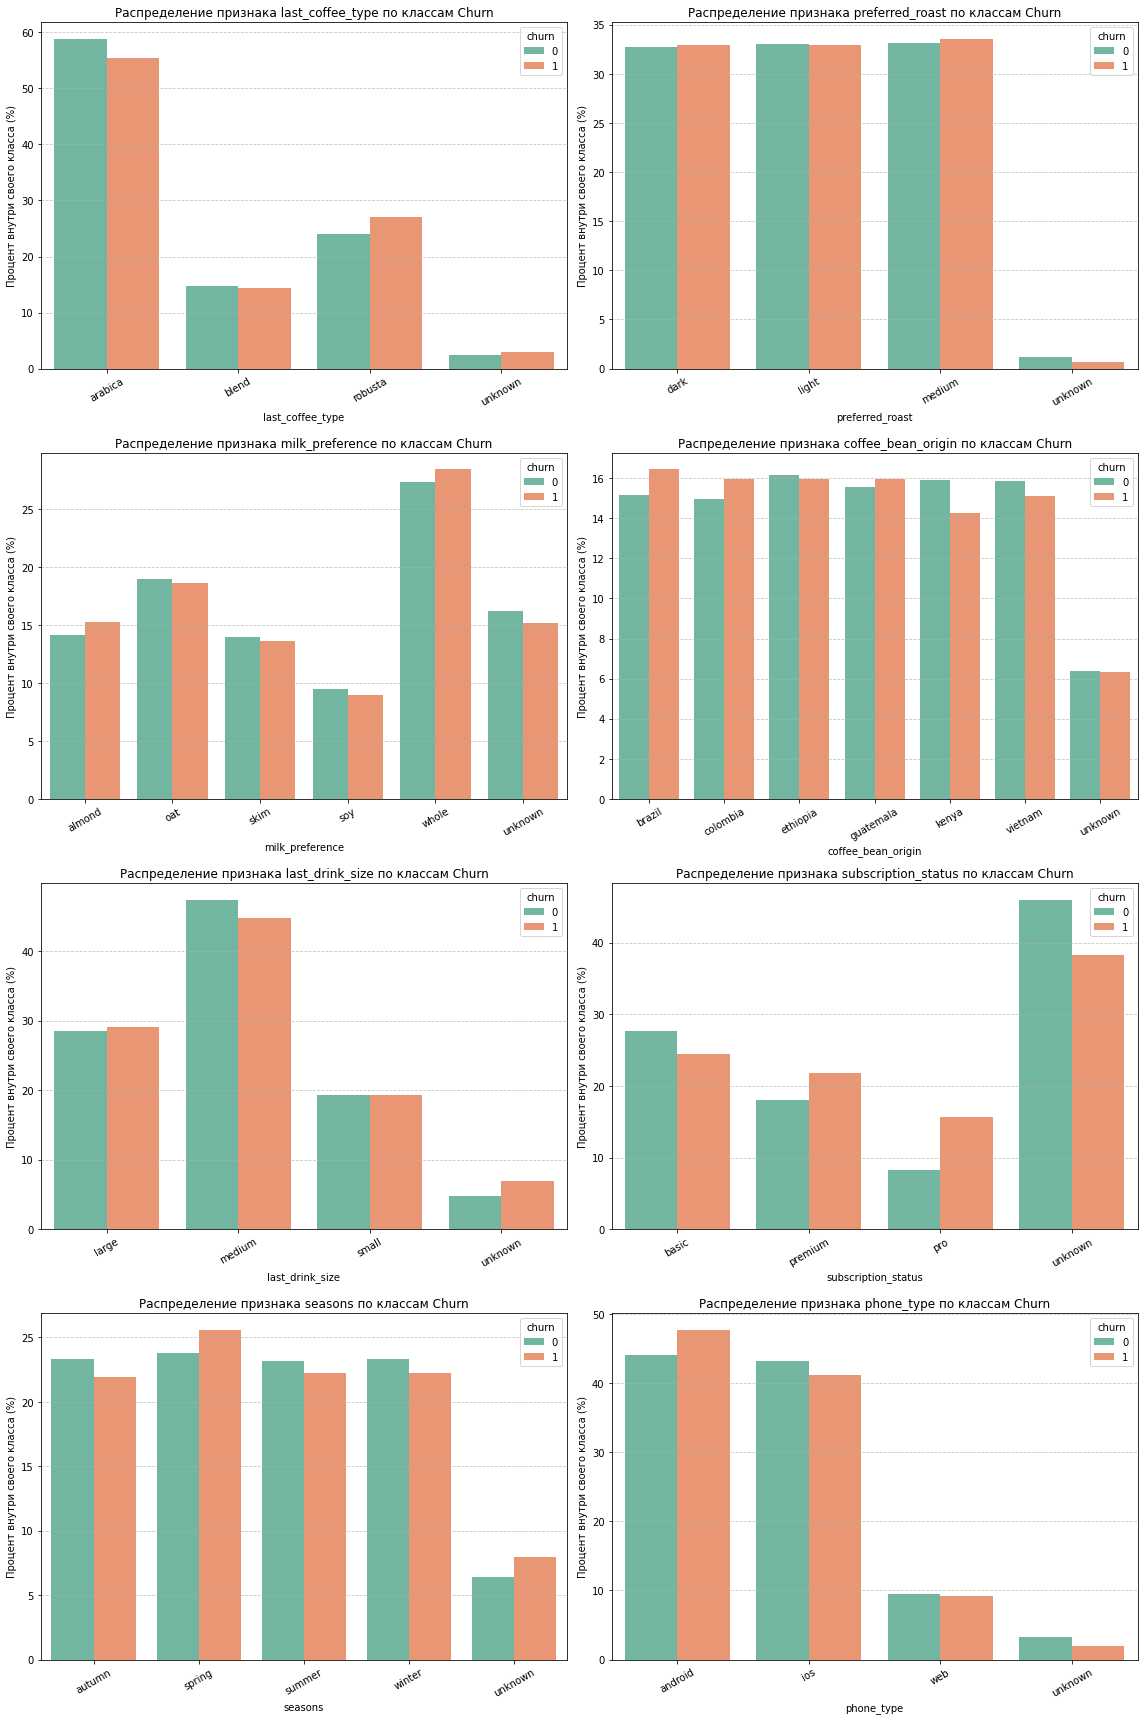

In [29]:
cat_vars_to_plot = list(CAT_VARS)
cat_vars_to_plot.remove('geo_id')

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 24))
axes = axes.flatten()

for i, var in enumerate(cat_vars_to_plot):
    # 1. Считаем проценты вручную через pandas:
    # Группируем по churn и считаем долю каждой категории внутри своего класса churn
    df_pct = (
        df.groupby('churn')[var]
        .value_counts(normalize=True)
        .rename('percent')
        .mul(100)
        .reset_index()
    )
        
    sns.barplot(
        x=var, 
        y='percent', 
        hue='churn', 
        data=df_pct, 
        ax=axes[i], 
        palette='Set2'
    )
    
    axes[i].set_title(f'Распределение признака {var} по классам Churn', fontsize=12)
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('Процент внутри своего класса (%)', fontsize=10)
    axes[i].tick_params(axis='x', rotation=30)  # поворачиваем подписи, чтобы не слипались
    axes[i].grid(axis='y', linestyle='--', alpha=0.7) # добавляем сетку

plt.tight_layout()
plt.show()

Явных аномалий в распределении категорийных признаков по классам churn 0, 1 не наблюдается. Почти всегда идёт распределение близкое к 50/50. Я бы отметил небольшой выброс в в **subscription_type = 'pro'** и немного **'premium'**. Среди таких подписчиков отток выше. Ещё выше отток клиентов на **android**, которые покупали **Бразильский или Колумбийский кофе** типа **rubusta** и предпочитают **whole milk**. А по сезонам немного выше **весной** и с **неуказанным сезоном**.

#### Непрерывные числовые признаки

Проверим пропуски.

In [30]:
get_missing_values_statistics(df, list(CONTINIOUS_VARS))

,"Пропущено (np.nan, None, pd.NA)",Доля пропусков %
total_spent_last_week,916,9.13
days_since_last_order,902,8.99
app_opens_per_week,857,8.54
review_rating_last_1,822,8.19
median_order_value,804,8.01
days_since_last_promo,698,6.95
app_crashes_last_month,694,6.92
review_rating_last_10,674,6.72
order_frequency_month,582,5.80
avg_order_value,560,5.58


👉 Пропуски будем заполнять в трансформере. Иначе нельзя будет завершить обработку признаков и обучение модели. Число пропусков по каждому признаку умеренное: <10%, а по ряду признаков ~6%. Способ заполнения уточним после анализа корреляций.

Сравним медианы непрерывных признаков по классам churn 0,1.

In [31]:
medians_by_churn = df.groupby("churn")[list(CONTINIOUS_VARS)].median().T
medians_by_churn.columns = ["Остались (0)", "Ушли (1)"]

# Считаем разницу в процентах относительно оставшихся клиентов
pct_diff = (
    (medians_by_churn.iloc[:, 1] - medians_by_churn.iloc[:, 0])
    .div(medians_by_churn.iloc[:, 0])
    .mul(100)
)

medians_by_churn["Разница (%)"] = pct_diff

# Сортируем по абсолютному значению разницы
medians_by_churn = medians_by_churn.reindex(
    medians_by_churn.iloc[:, 2].abs().sort_values(ascending=False).index
)

print("=== СРАВНЕНИЕ МЕДИАН ПРИЗНАКОВ С ПРОЦЕНТНЫМ РАЗРЫВОМ ===")
print(medians_by_churn.round({"Остались (0)": 2, "Ушли (1)": 2, "Разница (%)": 1}))

=== СРАВНЕНИЕ МЕДИАН ПРИЗНАКОВ С ПРОЦЕНТНЫМ РАЗРЫВОМ ===
                        Остались (0)     Ушли (1)  Разница (%)
app_crashes_last_month      1.000000     3.000000        200.0
app_opens_per_week          9.090000    11.680000         28.5
total_spent_last_week     284.420013   348.640015         22.6
total_spent_last_month   1278.630005  1516.400024         18.6
order_frequency_week        0.780000     0.910000         17.0
order_frequency_month       3.350000     3.870000         15.7
days_since_last_promo      10.000000    11.000000         10.0
review_rating_last_10       4.210000     4.140000         -1.6
avg_order_value           899.260010   885.609985         -1.5
median_order_value        405.880005   403.850006         -0.5
discount_usage_rate         0.260000     0.260000         -0.3
review_rating_last_1        3.990000     4.000000          0.3
days_since_last_order       3.000000     3.000000          0.0


👉 Непрерывные признаки показывают, что ушедшие клиенты на 200% чаще сталкивались с отказами приложения, на 28% чаще им пользовались и были значительно более активными в покупках: на ~20% больше тратили денег и на 17-18% чаще делали заказы кофе.

На первый взгляд, причиной оттока может быть наличие багов в приложениях B2C или недостатки хостинга, приводящие к медленной работе и отказам http code 500 и 503 под пиковыми нагрузками при максимальных RPM. Признак **app_crashes_last_month**.

Так же, у признаков **app_crashes_last_month, total_spent_last_week, total_spent_last_month, order_frequency_week, order_frequency_month, days_since_last_promo** наилучшая разделяющая способность для классов churn 0, 1. Но пока это кандидаты. Реальная разделяющая способность будет видна позже.

Теперь проверим выбросы у непрерывных признаков и распределения.

--- Визуализация: Часть 1 (5 перем.) ---


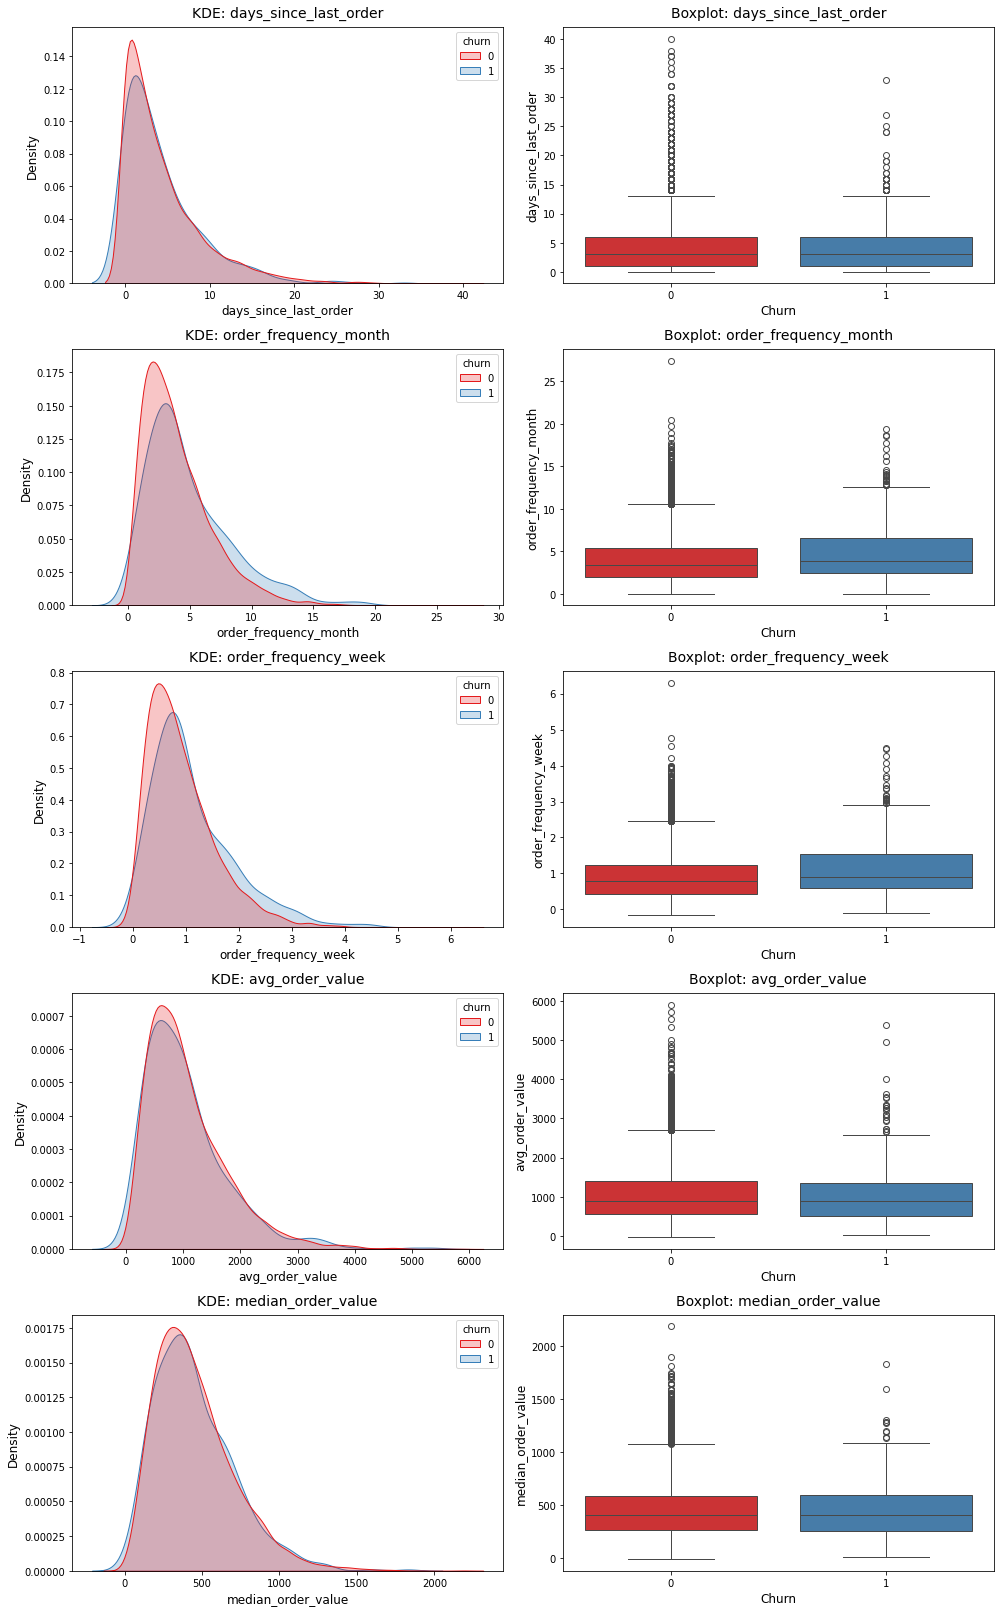

In [32]:
def plot_continuous_distributions(data_df, vars_list):
    """Функция для построения KDE и Boxplot для списка непрерывных переменных."""    
    num_vars = len(vars_list)
    nrows = num_vars
    ncols = 2

    # Создаем фигуру, высота адаптивно подстраивается под количество строк
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5 * nrows))
    axes = axes.flatten()

    ax_idx = 0
    for var in vars_list:
        # График KDE
        sns.kdeplot(
            data=data_df,
            x=var,
            hue="churn",
            fill=True,
            common_norm=False,
            palette="Set1",
            ax=axes[ax_idx],
        )
        axes[ax_idx].set_title(f"KDE: {var}", fontsize=14, pad=10)
        axes[ax_idx].set_xlabel(var, fontsize=12)
        axes[ax_idx].set_ylabel("Density", fontsize=12)

        # Boxplot для поиска выбросов
        sns.boxplot(
            data=data_df,
            x="churn",
            y=var,
            palette="Set1",
            hue="churn",
            legend=False,
            ax=axes[ax_idx + 1],
        )
        axes[ax_idx + 1].set_title(f"Boxplot: {var}", fontsize=14, pad=10)
        axes[ax_idx + 1].set_xlabel("Churn", fontsize=12)
        axes[ax_idx + 1].set_ylabel(var, fontsize=12)

        ax_idx += 2

    # Удаляем неиспользуемые оси
    for j in range(ax_idx, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


chunks = np.array_split(CONTINIOUS_VARS, 3) # чтобы не было вертикальной прокрутки

print(f"--- Визуализация: Часть 1 ({len(chunks[0])} перем.) ---")
plot_continuous_distributions(df, list(chunks[0]))  # Обязательно оборачиваем в list()

--- Визуализация: Часть 2 (4 перем.) ---


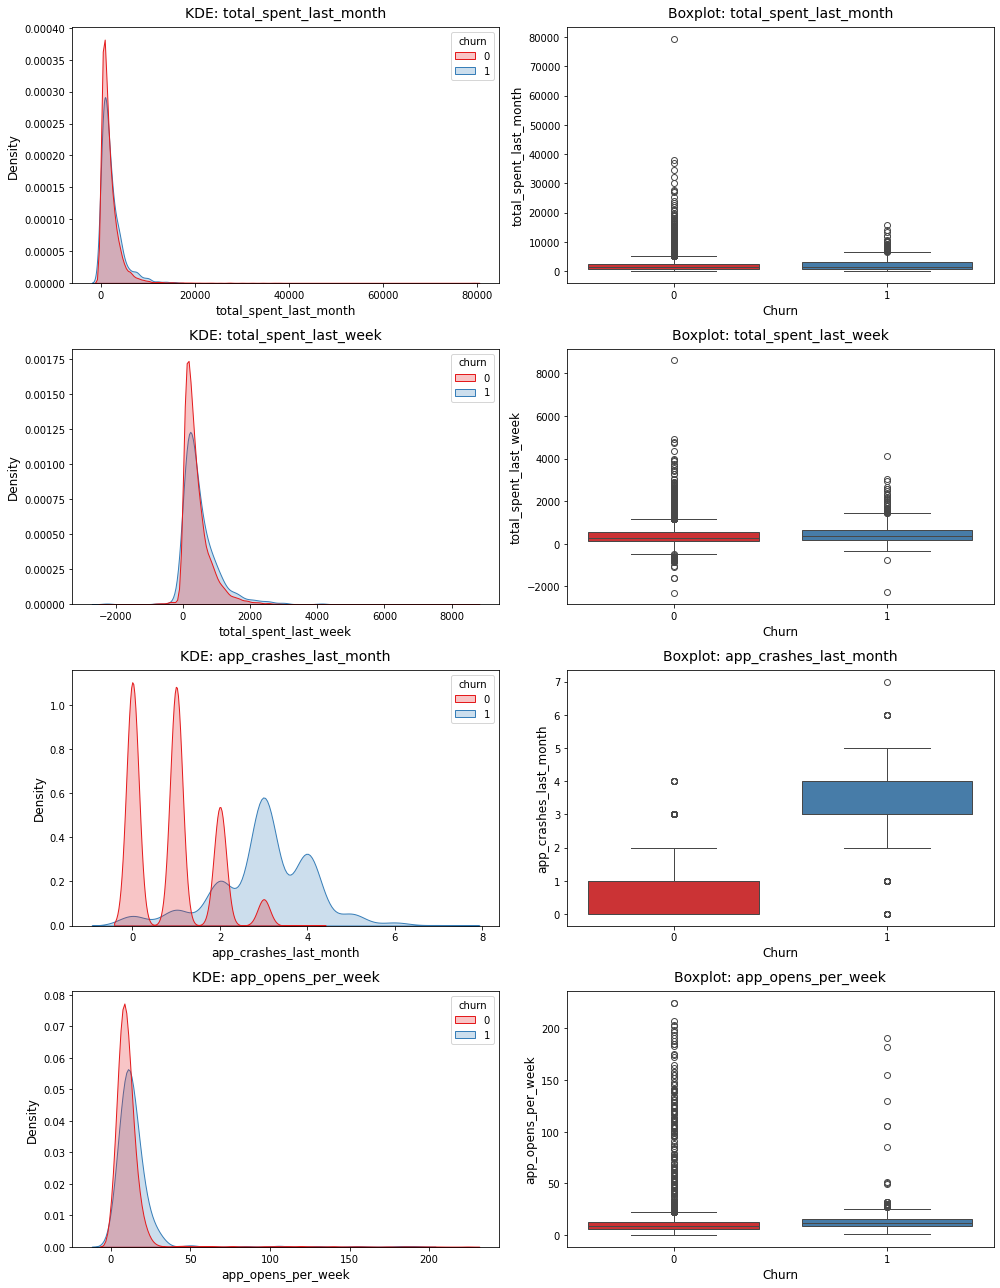

In [33]:
print(f"--- Визуализация: Часть 2 ({len(chunks[1])} перем.) ---")
plot_continuous_distributions(df, list(chunks[1]))

--- Визуализация: Часть 3 (4 перем.) ---


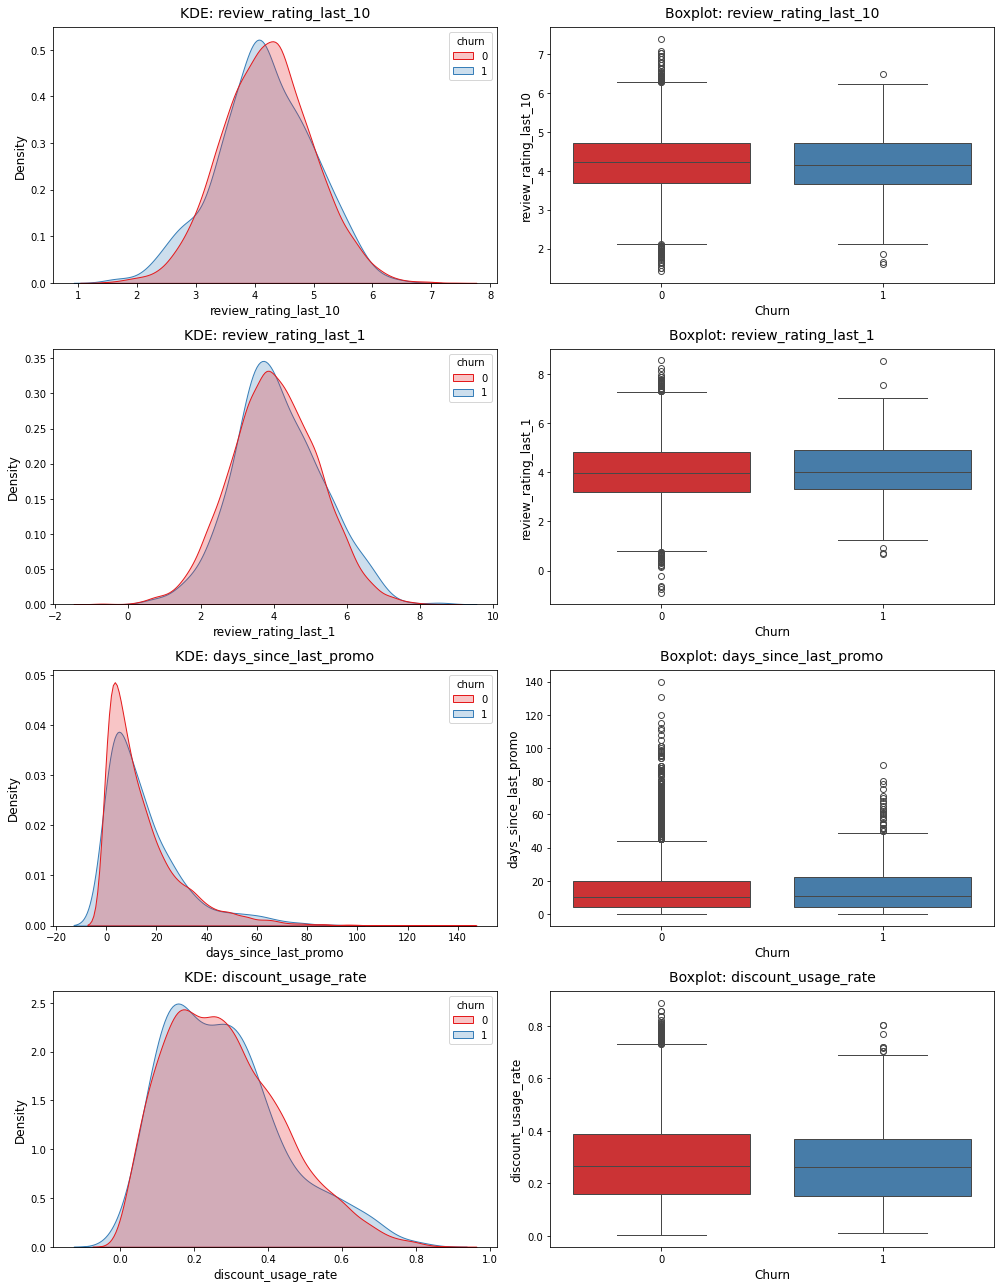

In [34]:
print(f"--- Визуализация: Часть 3 ({len(chunks[2])} перем.) ---")
plot_continuous_distributions(df, list(chunks[2]))

Большинство признаков имеют значительные выбросы справа и смещённые распределения, правостороннюю ассиметрию. У класса churn=1 выбросов несколько меньше.

review_rating_last_1 имеет нормальное распределение, но есть отрицательные значения в классе churn=0. review_rating_last_10 так же имеет нормальное распределение. В классе churn=1 мало выбросов. Проблемы только в churn=0.

**app_crashes_last_month** имеет мультимодальное распределение, но значения для churn=1 существенно больше и медиана выше. По пикам на KDE видно чёткое разделение классов churn, и ящик с усами это подтверждает. Это самый сильный признак, объясняющий отток.
days_since_last_promo - слабый признак в плане разделения классов.

Ещё посмотрим отрицательные значения

In [35]:
negative_cols = df[list(CONTINIOUS_VARS)].columns[(df[list(CONTINIOUS_VARS)] < 0).any()].tolist()

count_negative = (df[negative_cols] < 0).sum()
result = pd.DataFrame({
    'min_value': df[negative_cols].min(),
    'positive_median': df[negative_cols][df[negative_cols] > 0].median(),
    'negative_median': df[negative_cols][df[negative_cols] < 0].median(),
    'count_negative': count_negative,
    'pct_negative': (count_negative / len(df) * 100).round(2)
})

display(result.style.format({'pct_negative': '{:.2f}%'}))
total_pct = result["pct_negative"].sum()
print(f'Всего процентов от строк датасета: {total_pct:.2f}%')

has_missing = df[list(CONTINIOUS_VARS)].isna().any(axis=1)

# Считаем количество и процент
rows_with_at_least_one_missing = has_missing.sum()
pct_rows = (has_missing.mean() * 100).round(2)

print(f'Строк с хотя бы одним пропуском: {rows_with_at_least_one_missing} ({pct_rows:.2f}%)')

,min_value,positive_median,negative_median,count_negative,pct_negative
order_frequency_week,-0.169131,0.788159,-0.050134,74,0.74%
avg_order_value,-32.075932,898.568237,-28.523031,2,0.02%
median_order_value,-10.353340,405.881409,-8.839302,2,0.02%
total_spent_last_month,-43.716465,1295.181152,-29.227039,2,0.02%
total_spent_last_week,-2290.559570,293.562622,-90.322105,160,1.59%
review_rating_last_1,-0.897000,3.990018,-0.654883,5,0.05%


Всего процентов от строк датасета: 2.44%
Строк с хотя бы одним пропуском: 5869 (58.48%)


Достаточно много числовых непрерывных признаков имеют некорректные отрицательные значения, но в % от числа строк датасета совсем немного: 2.4%. Учитывая, что изначально 66% имеют пропуски, 2.5% не сыграют роли. По медианам видим, что скорее всего отрицательные - это ошибочные значения. Их медианы по модулю не похожи на медианы положительных значений.

👉 Очистим эти некорректные отрицательные значения и будем обрабатывать как пропуски. 

👉 Добавим в трасформер.

#### Промежуточный вывод

Выбросы искажают средние значения, при min-max нормализации приводят к сжатию более типичных значений около нуля, при нормализации увеличивается std, смещает среднее и многие данные теряют важность. Поэтому, выбросы надо обработать: отфильтровать по процентилю, либо учесть, преобразовав признак логарифмом или корнем. 

Преобразования будем делать в трансформере.

👉 Очистим отрицательные значения, выставив им NA.

👉 Заполним пропуски.

👉 Будем логарифмировать следующие признаки, в новые переменные, добавляя суффикс _log, а старые удалим:
 - days_since_last_order;
 
 - order_frequency_combo = (order_frequency_month + order_frequency_week * 4.33)/2
 
 - order_value_stability = median_order_value / (avg_order_value + 0.01)
 
 - weekly_spent_share = total_spent_last_week / (total_spent_last_month + 0.01)
 
 - app_opens_per_week;
 - days_since_last_promo.
 
👉 Оставим как есть то, что имеет нормальное распределение и/или не имеет сильных выбросов:
 - review_rating_last_10;
 - review_rating_last_1;
 - app_crashes_last_month;
 - discount_usage_rate.
 
👉 Затем, выполним клиппинг по квантилям **0.01, 0.99** всех непрерывных признаков, кроме:
  - review_rating_last_10;
  - review_rating_last_1;
  - app_crashes_last_month;
  - discount_usage_rate.
 

👉 К непрерывным признакам применем стандартизацию StandardScaler() в трансформере.

Порядок обработки: **Rename_cols(geo_location) --> Remove_100%_noise_cols(user_id) --> Reset_neg_values(NA) --> New_fields --> Imputer --> clip(0.01 и 0.99) --> lop1p --> Encode_categories (OneHotEncoder, drop='first') --> Scaler.**

#### Бинарные признаки

Сначала проверим пропуски у бинарных переменных.

In [36]:
get_missing_values_statistics(df, list(BINARY_VARS))

,"Пропущено (np.nan, None, pd.NA)",Доля пропусков %
seasonal_menu_tried,950,9.47
coffee_preference_change,582,5.80
notifications_enabled,514,5.12


👉 Пропуски будем заполнять в трансформере. Иначе нельзя будет завершить обработку признаков и обучение модели. Число пропусков умеренное <10%, а по ряду признаков ~5%.
Заполнять бинарные признаки будем модой: **SimpleImputer(strategy='most_frequent')**. Уточним после анализа корреляций.

Для бинарных признаков вместо сравнения медиан по классам churn, построим кросс таблицу.

In [37]:
for var in BINARY_VARS:
    print(f"\n--- Таблица сопряженности для {var} (в процентах) ---")
    
    # normalize='index': распределение оттока внутри значений 0 и 1 самого признака
    ct = pd.crosstab(df[var], df["churn"], normalize="index") * 100
    ct = ct.map(lambda x: f"{x:.2f}%")
    
    print(ct.round(2))


--- Таблица сопряженности для seasonal_menu_tried (в процентах) ---
churn                     0      1
seasonal_menu_tried               
0.0                  93.69%  6.31%
1.0                  93.95%  6.05%

--- Таблица сопряженности для notifications_enabled (в процентах) ---
churn                       0      1
notifications_enabled               
0.0                    93.74%  6.26%
1.0                    94.10%  5.90%

--- Таблица сопряженности для coffee_preference_change (в процентах) ---
churn                          0      1
coffee_preference_change               
0.0                       94.07%  5.93%
1.0                       93.92%  6.08%


Построим столбчатые диаграммы вместо KDE, чтобы увидеть доли оттока внутри каждой группы 0, 1 бинарных признаков.

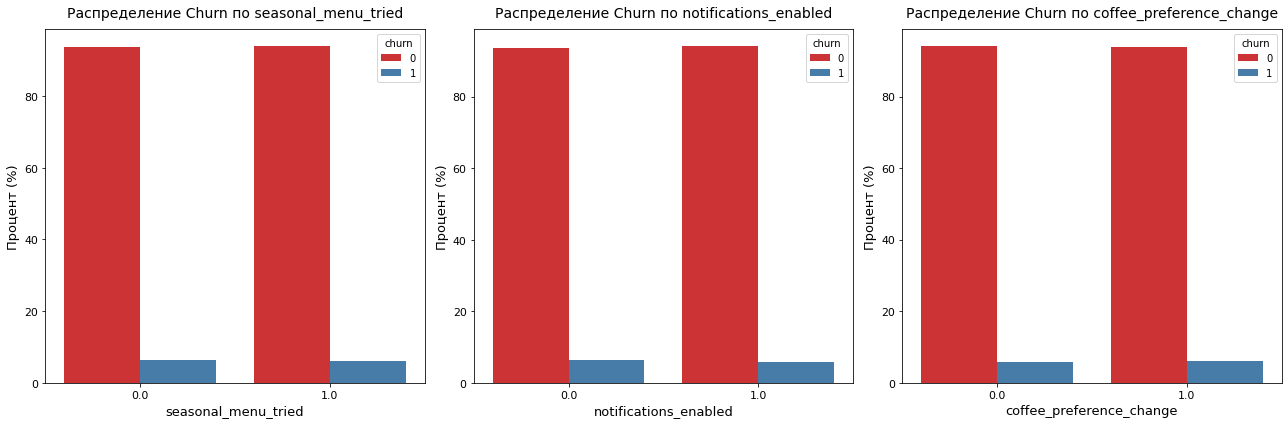

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
axes = axes.flatten()

for idx, var in enumerate(BINARY_VARS):
    # Считаем пропорции churn внутри каждой группы бинарного признака
    prop_df = (
        df.groupby(var)["churn"]
        .value_counts(normalize=True)
        .rename("percentage")
        .reset_index()
    )
    prop_df["percentage"] *= 100

    # Строим график
    sns.barplot(
        data=prop_df,
        x=var,
        y="percentage",
        hue="churn",
        palette="Set1",
        ax=axes[idx],
    )

    # Настройки шрифтов (увеличенные размеры)
    axes[idx].set_title(f"Распределение Churn по {var}", fontsize=14, pad=12)
    axes[idx].set_ylabel("Процент (%)", fontsize=13)
    axes[idx].set_xlabel(var, fontsize=13)

    # Делаем крупнее сами деления (цифры 0, 1, 20, 40 и т.д.) на осях
    axes[idx].tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()

👉 Бинарные признаки не значимы и не объясняют отток, так как почти не меняются для классов churn 0, 1. Они бесполезны и их можно удалить. Однако, силу признаков мы будем определять отдельно, после разделения выборок на обучающую и тестовую. В идеале, даже внутри кросс-валидации каждый раз заново.

Пока отметим, что **'seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change'** бесполезны.

#### Проверка коллинеарности признаков

In [39]:
base_fields = list(CONTINIOUS_VARS) + list(BINARY_VARS)

# категориальные признаки 
cat_fields_to_encode = [c for c in CAT_VARS if c != "geo_id"]

# One-Hot Encoding для категорий
df_encoded = pd.get_dummies(
    df[base_fields + cat_fields_to_encode],
    columns=cat_fields_to_encode,
    drop_first=True,  # удаляем базовую категорию, чтобы избежать искусственной коллинеарности
    dtype=float,
)

display(check_vif(df_encoded, df_encoded.columns, top=7))

del df_encoded
del base_fields
del cat_fields_to_encode
gc.collect()

,Feature,VIF
2,order_frequency_week,45.896734
1,order_frequency_month,45.223313
4,median_order_value,5.459335
3,avg_order_value,4.220807
5,total_spent_last_month,3.958884
6,total_spent_last_week,3.779012
25,milk_preference_whole,2.146728


129024

👉 order_frequency_week и order_frequency_month коллинеарны VIF > 10, критический уровень. 

Признаки схожи, поэтому один можно удалить из модели, оставив более сильный по разнице между медианами на классах churn 0, 1:

```
                          Остались (0)     Ушли (1)  Разница (%)
 order_frequency_week        0.780000     0.910000         17.0
 order_frequency_month       3.350000     3.870000         15.7
```

Это order_frequency_week. Но лучше заменим эти два признака на производный признак, чтобы сохранить инофрмацию в данных, избавившись от коллинеарности. Введём усреднённый показатель:

**order_frequency_combo = (order_frequency_month + order_frequency_week * 4.33) / 2**  - (здесь 4.33 недели в месяце)

👉 Добавим это в трансформер. Старые колонки удалим.                    

Теперь проверим ещё корреляцию между признаками.

Рассчитываю матрицу Phik...


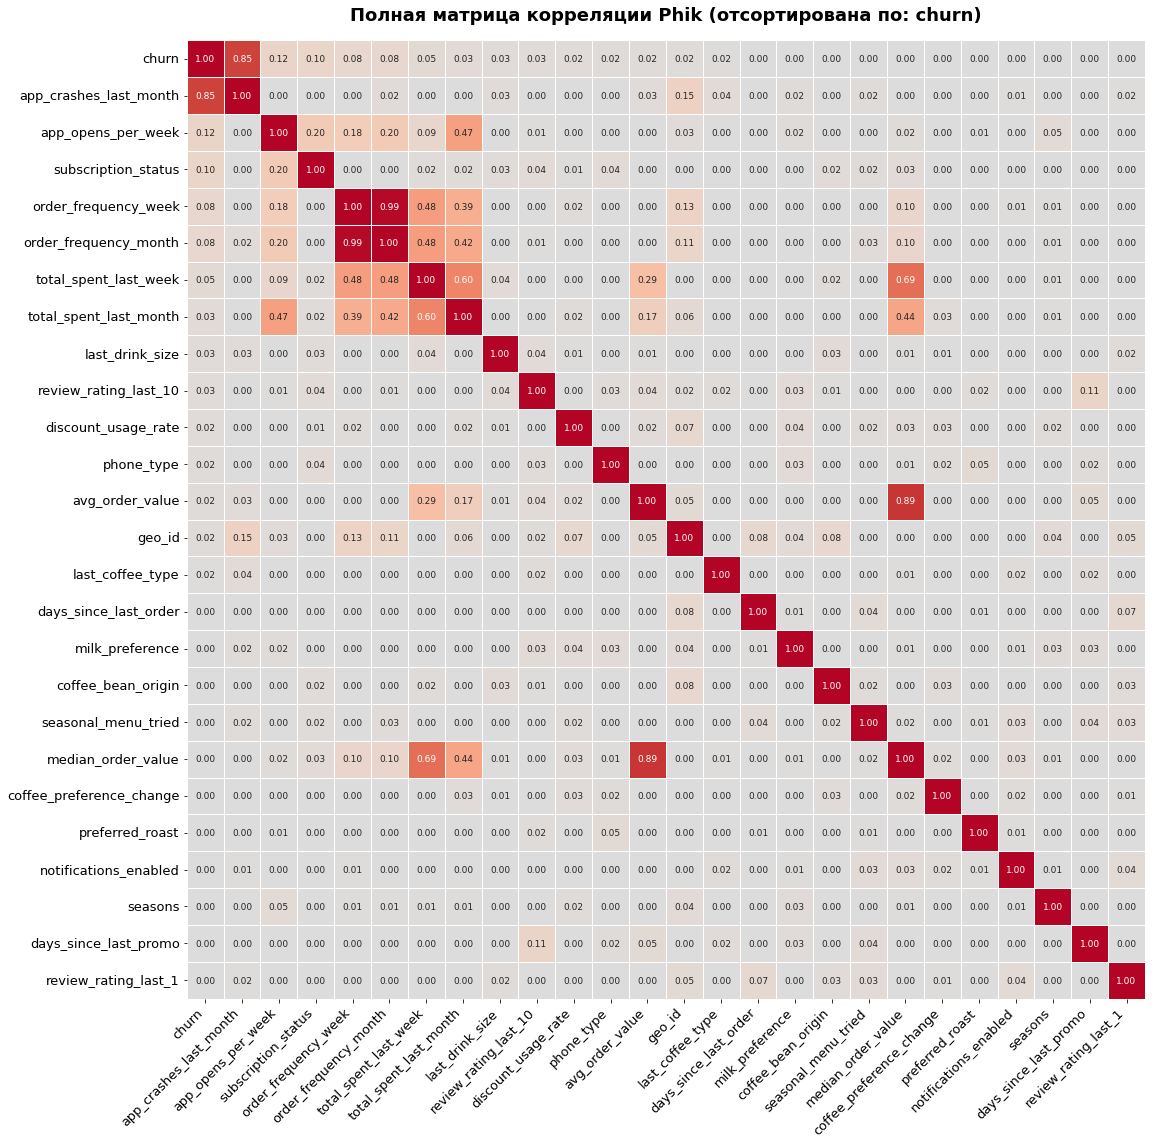

In [40]:
ALL_FEATURES = list(CONTINIOUS_VARS) + list(BINARY_VARS) + list(CAT_VARS)

show_full_phik_heatmap(
    df=df,
    fields=ALL_FEATURES,
    target_field=TARGET,
    continuous_fields=CONTINIOUS_VARS,
    figsize=(24, 16),
);

👉 Теперь видим корреляции (0.51 и выше): median_order_value и total_spent_last_week, total_spent_last_month, avg_order_value.

В трансформере заменим эти переменные:
 - **order_value_stability = median_order_value / (avg_order_value + 0.01)** (коэффициент симметрии);
 - **weekly_spent_share = total_spent_last_week / (total_spent_last_month + 0.01)** (доля месячных расходов за последнюю неделю).
 
 Исходные переменные удалим.
 
 Корреляции есть, поэтому, теперь уточним способ заполнения пропусков в числовых колонках. Вычисления будем делать на Traning set в трансформере.

In [41]:
display(get_missing_values_statistics(df))

,"Пропущено (np.nan, None, pd.NA)",Доля пропусков %
seasonal_menu_tried,950,9.47
total_spent_last_week,916,9.13
days_since_last_order,902,8.99
app_opens_per_week,857,8.54
review_rating_last_1,822,8.19
median_order_value,804,8.01
days_since_last_promo,698,6.95
app_crashes_last_month,694,6.92
review_rating_last_10,674,6.72
order_frequency_month,582,5.80


👉 Уточнение заполнения пропусков в числовых признаках:

Категория | Поля | Как заполнять | Обоснование
---|---|---|---
**Технические проблемы** | `app_crashes_last_month` | `0` (заглушка) + `add_indicator=True` | Пропуск скорее всего означает, что сбоев приложения не было.
**Временные интервалы** | `days_since_last_order`, `days_since_last_promo` | `999` (заглушка) + `add_indicator=True` | Новые клиенты, которые ещё не успели сделать заказ или использовать промо.
**Все остальные числовые** | `order_frequency_month`, `order_frequency_week`, `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `app_opens_per_week`, `discount_usage_rate`, `review_rating_last_10`, `review_rating_last_1` | `IterativeImputer` (с `RandomForestRegressor`) | Есть небольшая корреляции между признаками, MAR-пропуски. `IterativeImputer` восстановит пропуски, используя все числовые переменные.
**Бинарные** | `seasonal_menu_tried`, `notifications_enabled`, `coffee_preference_change` | Общая мода | Слабые корреляции, MAR-пропуски.
**Категориальные** | `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size`, `subscription_status`, `seasons`, `phone_type`, `geo_location` | Заполнить пропуски строкой `'unknown'` | Добавляем новую категорию для неизвестных значений.

👉 Уточнение нормализации непрерывных числовых колонок:

| Преобразование | Колонки | Обоснование |
|---|---|---|
| **StandardScaler** | `order_frequency_combo_log`, `order_value_stability_log`, `weekly_spent_share_log`, `review_rating_last_10`, `review_rating_last_1`, `app_crashes_last_month`, `geo_id`, `app_opens_per_week_log` | Логарифм сжимает выбросы и симметризует распределение, после чего StandardScaler (среднее=0, std=1) приводит признаки к единому масштабу без потери информации о разбросе — оптимально для линейных моделей. Рейтинги имеют нормальное распределение (KDE-колокол), но реальный диапазон НЕ ограничен 1–5 (describe: min=−0.9, max=8.56). `app_crashes_last_month` — счётчик 0–7 с сильным линейным разделением классов, выбросов мало → Standard сохраняет линейную связь лучше Robust. `geo_id` кодируется TargetEncoder средней долей таргета → при churn≈6% значения лежат в узком диапазоне ~[0, 0.2]; без стандартизации логрег компенсировал бы это завышенным весом, искажая L1-отбор и интерпретацию. |
| **RobustScaler**<br>(устойчив к выбросам) | `days_since_last_order_log`, `days_since_last_promo_log` | В `days_since_last_*_log` «полка» от замены пропусков (log1p(999)≈6.9). RobustScaler использует медиану и IQR, поэтому полка и хвосты не исказят масштаб остальных значений.  → Robust устойчивее, чем Standard. |
| **MinMaxScaler**<br>(диапазон [0, 1]) | `discount_usage_rate` | Единственный признак с реально ограниченным физическим диапазоном [0, ~0.9] (доля заказов со скидкой), лёгкий правый скос, выбросов мало → MinMax приводит к [0,1] без искажения. Диапазон [0,1] выбран намеренно: он согласован с бинарными и OHE-признаками, что обеспечивает «справедливую» регуляризацию (для линейной модели конкретный `feature_range` на предсказания не влияет — важна согласованность масштабов между признаками). |
| **Без масштабирования**<br>(`remainder='passthrough'`) | • Все бинарные колонки после OneHotEncoder (кроме `geo_id`).<br>• Исходные бинарные признаки: `seasonal_menu_tried`, `notifications_enabled`, `coffee_preference_change`.<br>• Индикаторы пропусков `*_was_na` (шаги 8–9). | Эти признаки уже находятся в диапазоне {0,1} и согласованы по масштабу с MinMax-фичами. Дополнительное масштабирование не требуется — оставляем как есть ради интерпретируемости коэффициентов и во избежание лишних преобразований. |

Признак | Способ кодирования | Обоснование
---|---|---
`geo_location` | Target Encoding (с сглаживанием) | Уникальных регионов много (> 50), One-Hot создаст слишком много бинарных колонок, увеличит размерность и может привести к переобучению. Target Encoding заменяет категорию на среднее значение целевой переменной (churn) в этой категории с регуляризацией. 
Все остальные категориальные: `last_coffee_type`, `preferred_roast`, `milk_preference`, `coffee_bean_origin`, `last_drink_size`, `subscription_status`, `seasons`, `phone_type` | `OneHotEncoder` с `drop='first'` | Количество уникальных значений в этих колонках невелико (обычно 3–6). One-Hot кодирование даёт интерпретируемые бинарные признаки без потери информации и без сильного увеличения размерности. Параметр `drop='first'` убирает одну категорию, чтобы избежать мультиколлинеарности в линейных моделях.

In [42]:
df[['review_rating_last_10', 'review_rating_last_1']].describe()

,review_rating_last_10,review_rating_last_1
count,9362.000000,9214.000000
mean,4.207272,4.022551
std,0.782584,1.205782
min,1.415526,-0.897000
25%,3.675187,3.217563
50%,4.205958,3.989636
75%,4.718466,4.844709
max,7.384425,8.558442


### Промежуточный вывод

Проведённый анализ данных позволил выявить особенности датасета, определить основные проблемы в данных и наметить способы их решения для обучения модели прогнозирования оттока.

#### Структура и качество данных
*   **Размер данных:** датасет содержит 10 450 строк и 27 признаков.
*   **Колонки:** имена в snake case, одна колонка переименована: 'geo_location' --> 'geo_id'.
*   **Дубликаты:** обнаружено и удалено 414 полных дубликатов строк, отличающихся только `user_id`.
*   **Технические идентификаторы:** признак `user_id` удалён как не несущий полезной информации для модели.
*   **Пропуски:** зафиксированы пропуски в большинстве признаков, кроме целевой переменной. Их доля варьируется от незначительной (<5%) до умеренной (<10%). Принято решение заполнять пропуски в трансформерах: для непрерывных признаков индивидуально и через IterativeImputer, для категориальных — категорией `unknown`, для бинарных — модой.
*   **Типы данных:** проведена оптимизация типов данных, что позволило на 50% снизить объём потребляемой памяти.

После начальной обработки в датасете осталось **10 036** строк и **26** колонок.

#### 2. Целевая переменная (`churn`)
*   Подтверждён критический дисбаланс: доля ушедших клиентов (класс 1) составляет всего **6%** от общего числа. Это обосновывает выбор **PR-AUC** в качестве основной метрики и требует осторожного подхода к оценке точности (Precision/Recall).

#### 3. Анализ признаков и их значимость
*   **Категориальные признаки:** выявлены и обработаны неявные пропуски (значение `'none'` в `subscription_status`). Предварительный анализ показал, что отток немного выше среди пользователей с подписками `pro` и `premium`, предпочитающих цельное молоко и зёрна из Бразилии и Колумбии.
*   **Непрерывные признаки:** признаки имеют правостороннюю асимметрию, содержат выбросы и некорректные отрицательные значения, что требует исправления клиппинга по квантилям 0.01, 0.99 и логарифмирования. Сравнение медиан показало, что ушедшие клиенты в среднем на **200% чаще сталкиваются с зависаниями приложения** (`app_crashes_last_month`) и имеют более высокую активность в приложении. 

* Признаки **app_crashes_last_month, app_crashes_last_month, total_spent_last_week, total_spent_last_month, order_frequency_week, order_frequency_month, days_since_last_promo** имеют наилучшую разделяющую способность для классов churn 0, 1.

*   **Бинарные признаки:** предварительный анализ показал, что признаки `seasonal_menu_tried`, `notifications_enabled` и `coffee_preference_change` практически не разделяют классы и, вероятно, будут удалены как неинформативные.

Окончательный отбор значимых признаков для обучения модели будет выполняться в трансформерах, так как там будут собраны необходимые преобразования (нормализация, кодирование категорий, заполнение пропусков, замена на производные признаки).

#### 4. Мультиколлинеарность и корреляции
*   Выявлена критическая мультиколлинеарность (VIF > 10) между признаками **`order_frequency_week`** и **`order_frequency_month`**, а также высокие корреляции (0.51 по phik) между финансовыми показателями (**median_order_value и total_spent_last_week, total_spent_last_month, avg_order_value**).
*   **Решение:** Принято решение не удалять такие признаки, а заменить производными признаками (`order_frequency_combo`, `order_value_stability`, `weekly_spent_share`) каждую пару связанных признаков, чтобы сохранить информацию и избавиться от избыточности, которая может приводить к переобучению модели или нестабильным весам признаков.

#### План дальнейших действий
Разработать пайплайн предобработки, который будет включать: заполнение пропусков, логарифмирование и клиппинг выбросов для числовых признаков, кодирование категорий (`One-Hot Encoding` и `Target Encoding` для `geo_id`), масштабирование (`StandardScaler` и индивидуально MinMaxScaler и RobustScaler) и конструирование новых признаков. Добавить в трансформеры шаг удаления малозначимых признаков через **LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced')**.  Проверить корреляцию и коллениарность заново. Затем приступить к обучению модели логистической регрессии.

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



### Переменные

In [43]:
CAT_OHE_VARS = tuple(c for c in CAT_VARS if c != 'geo_id') # geo_id кодируется через TargetEncoder
NEW_VARS = ('order_frequency_combo', 'order_value_stability', 'weekly_spent_share')
DROP_AFTER_FE1_VARS = (
    'order_frequency_month', 'order_frequency_week', 'avg_order_value',
    'median_order_value', 'total_spent_last_month', 'total_spent_last_week',
)
LOG_VARS = (
    'days_since_last_order', 'order_frequency_combo', 'order_value_stability',
    'weekly_spent_share', 'app_opens_per_week', 'days_since_last_promo',
)
CONTINIOUS_VARS_FEAT = tuple((set(CONTINIOUS_VARS) - set(DROP_AFTER_FE1_VARS)) | set(NEW_VARS))

CLIP_EXCLUDE_VARS = (
    'review_rating_last_10', 'review_rating_last_1',
    'app_crashes_last_month', 'discount_usage_rate',
)
CLIP_VARS = tuple(c for c in CONTINIOUS_VARS_FEAT if c not in CLIP_EXCLUDE_VARS)

IMPUTER_EXCLUDE_VARS = ('days_since_last_order', 'days_since_last_promo', 'app_crashes_last_month')
IMPUTER_VARS = tuple(c for c in CONTINIOUS_VARS_FEAT if c not in IMPUTER_EXCLUDE_VARS)

IMPUTER_VARS_NOFE = tuple(c for c in CONTINIOUS_VARS if c not in IMPUTER_EXCLUDE_VARS)
CLIP_VARS_NOFE = tuple(c for c in CONTINIOUS_VARS if c not in CLIP_EXCLUDE_VARS)

### Разделение датасета

In [44]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=SEED)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"✅ Доля churn в train: {y_train.mean():.3f}")

train: (8028, 25), test: (2008, 25)
✅ Доля churn в train: 0.060


### Трансформеры

#### Простые трансформеры

In [45]:
def pathch_columns(df):
    ren_dict = {'geo_location': 'geo_id'} if 'geo_location' in df.columns else {}
    drop_list = ['user_id'] if 'user_id' in df.columns else []
    
    return df.copy().rename(columns=ren_dict).drop(columns=drop_list)

def types_to_nampy(df, num_vars, cat_vars, bin_vars):
    df = df.copy()
    for col in num_vars:
        if col in df.columns:
            df[col] = df[col].astype(np.float64)
            
    for col in bin_vars:
        if col in df.columns:
            # безопасно для NaN, внутри ModeImputer после заполнения пропусков будет int8
            df[col] = df[col].astype(np.float64) 
            
    for col in cat_vars:
        if col in df.columns:
            df[col] = df[col].astype('category')
            
    return df

def reset_negative(df, vars):
    df = df.copy()
    for col in vars:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan
            
    return df

#### Кастомные трансформеры

In [46]:
class CatImputer(BaseEstimator, TransformerMixin):
    """NA и неявный 'none' (subscription_status) -> категория 'unknown'."""

    def __init__(self, cat_vars):
        self.cat_vars = cat_vars

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        for col in self.cat_vars:
            if col not in X.columns:
                continue
            X[col] = X[col].astype('object')
            if col == 'subscription_status':
                X[col] = X[col].replace('none', np.nan)
            X[col] = X[col].fillna('unknown').astype('category')

        return X
    
class PairedFieldsImputer(BaseEstimator, TransformerMixin):
    """Восстанавливает одно пропущенное значение пары на основе связанного."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        m, w = 'order_frequency_month', 'order_frequency_week'
        mask = X[w].isna() & X[m].notna()
        X.loc[mask, w] = X.loc[mask, m] / 4.333
        mask = X[m].isna() & X[w].notna()
        X.loc[mask, m] = X.loc[mask, w] * 4.33

        a, md = 'avg_order_value', 'median_order_value'
        mask = X[a].isna() & X[md].notna()
        X.loc[mask, a] = X.loc[mask, md]
        mask = X[md].isna() & X[a].notna()
        X.loc[mask, md] = X.loc[mask, a]

        tm, tw = 'total_spent_last_month', 'total_spent_last_week'
        mask = X[tm].isna() & X[tw].notna()
        X.loc[mask, tm] = X.loc[mask, tw] * 4.33
        mask = X[tw].isna() & X[tm].notna()
        X.loc[mask, tw] = X.loc[mask, tm] / 4.33

        return X
    
class FeatureEngineer1(BaseEstimator, TransformerMixin):
    """Создаёт комбинированные признаки и удаляет исходные."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['order_frequency_combo'] = (
            X['order_frequency_month'] + X['order_frequency_week'] * 4.33
        ) / 2
        X['order_value_stability'] = (
            X['median_order_value'] / (X['avg_order_value'] + 0.01)
        )
        X['weekly_spent_share'] = (
            X['total_spent_last_week'] / (X['total_spent_last_month'] + 0.01)
        )
        return X.drop(columns=list(DROP_AFTER_FE1_VARS))
    
class ConstantIndicatorImputer(BaseEstimator, TransformerMixin):
    """Заполняет колонки константой, добавляя индикатор пропусков *_was_na."""

    def __init__(self, cols, fill_value):
        self.cols = cols
        self.fill_value = fill_value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        
        for col in self.cols:
            if col not in X.columns:
                continue
            X[f'{col}_was_na'] = X[col].isna().astype(np.int8)
            X[col] = X[col].fillna(self.fill_value)
            
        return X
    
class IterativeImputerDF(BaseEstimator, TransformerMixin):
    """IterativeImputer (BayesianRidge по умолчанию) на явном списке полей."""

    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        self.cols_ = [c for c in self.cols if c in X.columns]
        self.imputer_ = IterativeImputer(max_iter=10, random_state=SEED)
        self.imputer_.fit(X[self.cols_])
        
        return self

    def transform(self, X):
        X = X.copy()
        X[self.cols_] = self.imputer_.transform(X[self.cols_])
        
        return X
    
class ModeImputer(BaseEstimator, TransformerMixin):
    """Заполняет бинарные признаки модой по каждой колонке."""

    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        self.modes_ = {
            c: X[c].mode(dropna=True).iloc[0]
            for c in self.cols if c in X.columns
        }
        return self

    def transform(self, X):
        X = X.copy()
        
        for c, m in self.modes_.items():
            X[c] = X[c].fillna(m).astype(np.int8)
            
        return X
    
class PercentileClipper(BaseEstimator, TransformerMixin):
    """Clip по перцентилям (0.01, 0.99) для заданных колонок."""

    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.bounds_ = {
            c: (X[c].quantile(self.lower), X[c].quantile(self.upper))
            for c in self.cols if c in X.columns
        }

        return self

    def transform(self, X):
        X = X.copy()

        for c, (lo, hi) in self.bounds_.items():
            X[c] = X[c].clip(lo, hi)

        return X
    
class LogTransformer(BaseEstimator, TransformerMixin):
    """log1p для указанных полей: исходное удаляется, добавляется *_log."""

    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        
        for c in self.cols:
            if c in X.columns:
                X[f'{c}_log'] = np.log1p(X[c].clip(lower=0))
                X = X.drop(columns=[c])
                
        return X

#### Пайплайны

In [47]:
def build_encode_scale(feature_engineering):
    """Шаги 14-15 пайплайна."""
    
    minmax_cols = ['discount_usage_rate']
        
    # если build_encode_scale= True, то используем логарифмирование и замену колонок 
    if feature_engineering:
        standard_cols = [
            'order_frequency_combo_log', 'order_value_stability_log',
            'weekly_spent_share_log', 'app_opens_per_week_log',
            'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month',
        ]
        robust_cols = ['days_since_last_order_log', 'days_since_last_promo_log']
    else:
        standard_cols = [
            'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month',
        ]
        robust_cols = [
            'days_since_last_order', 'days_since_last_promo', 'app_opens_per_week',
            'order_frequency_month', 'order_frequency_week',
            'avg_order_value', 'median_order_value',
            'total_spent_last_month', 'total_spent_last_week',
        ]
    
    geo_pipe = Pipeline([
        ('target', TargetEncoder(random_state=SEED)),
        ('scale', StandardScaler()),
    ])

    return ColumnTransformer(
        transformers=[
            ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore',
                                  sparse_output=False), list(CAT_OHE_VARS)),
            ('geo', geo_pipe, ['geo_id']),
            ('standard', StandardScaler(), standard_cols),
            ('robust', RobustScaler(), robust_cols),
            ('minmax', MinMaxScaler(feature_range=(0, 1)), minmax_cols),
        ],
        remainder='passthrough',
        verbose_feature_names_out=False,
    ).set_output(transform='pandas')

def ft(func, **kwargs):
    """Хелпер для создания FunctionTransformer"""
    return FunctionTransformer(func, kw_args=kwargs).set_output(transform='pandas')

In [48]:
# ---------- Полный препроцессинг (с логарифмированием и заменой полей) ----------
preprocess_full = Pipeline(steps=[
    ('rename_drop', ft(pathch_columns)),                       # 1-2
    ('convert', ft(types_to_nampy, num_vars=CONTINIOUS_VARS, cat_vars=CAT_VARS, bin_vars=BINARY_VARS)),                             # 3
    ('reset_neg', ft(reset_negative, vars=CONTINIOUS_VARS)),     # 4
    ('cat_impute', CatImputer(CAT_VARS)),                               # 5
    ('paired', PairedFieldsImputer()),                          # 6
    ('fe1', FeatureEngineer1()),                                # 7
    ('crash_impute', ConstantIndicatorImputer(
        cols=['app_crashes_last_month'], fill_value=0)),        # 8
    ('days_impute', ConstantIndicatorImputer(
        cols=['days_since_last_order', 'days_since_last_promo'],
        fill_value=999)),                                       # 9
    ('iter_impute', IterativeImputerDF(cols=IMPUTER_VARS)),        # 10
    ('mode_impute', ModeImputer(cols=BINARY_VARS)),                # 11
    ('clip', PercentileClipper(cols=CLIP_VARS)),                # 12
    ('log', LogTransformer(cols=LOG_VARS)),                       # 13
    ('encode_scale', build_encode_scale(True)),               # 14-15
])

# ---------- Препроцессинг без логарифмирования и новых колонок ----------
preprocess_nofe = Pipeline(steps=[
    ('rename_drop', ft(pathch_columns)),                       # 1-2
    ('convert', ft(types_to_nampy, num_vars=CONTINIOUS_VARS, cat_vars=CAT_VARS, bin_vars=BINARY_VARS)),                             # 3
    ('reset_neg', ft(reset_negative, vars=CONTINIOUS_VARS)),    # 4
    ('cat_impute', CatImputer(CAT_VARS)),                               # 5
    ('paired', PairedFieldsImputer()),                          # 6
    ('crash_impute', ConstantIndicatorImputer(
        cols=['app_crashes_last_month'], fill_value=0)),        # 8
    ('days_impute', ConstantIndicatorImputer(
        cols=['days_since_last_order', 'days_since_last_promo'],
        fill_value=999)),                                       # 9
    ('iter_impute', IterativeImputerDF(cols=IMPUTER_VARS_NOFE)),   # 10
    ('mode_impute', ModeImputer(cols=BINARY_VARS)),                # 11
    ('clip', PercentileClipper(cols=CLIP_VARS_NOFE)),           # 12
    ('encode_scale', build_encode_scale(False)),            # 14-15
])

#### Модель


In [49]:
def build_selector():
    """Шаг 16: L1-отбор важных признаков, согласованный с финальной моделью."""
    return SelectFromModel(
        estimator=LogisticRegression(
            penalty='l1', solver='liblinear', C=0.5,
            class_weight='balanced', max_iter=2000, random_state=SEED,
        ),
        threshold='median',
    )

def build_logreg_model(class_weight='balanced'):
    """Учтён дисбаланс 6% и сходимость saga."""
    return LogisticRegression(
        class_weight=class_weight, max_iter=5000, random_state=SEED
    )


def make_full_pipeline(preprocess, classifier_model, *, use_selector = False):
    """Финальный пайплайн: препроцессинг -> (SelectFromModel) -> модель."""
    steps = [('preprocess', clone(preprocess))]
    if use_selector:
        steps.append(('select', build_selector()))
    steps.append(('clf', classifier_model))
    
    return Pipeline(steps, memory=memory)


def make_dummy_pipeline(preprocess):
    return Pipeline(
        [
            ('preprocess', clone(preprocess)),
            ('clf', DummyClassifier(strategy='most_frequent', random_state=SEED)),
        ],
        memory=memory,
    )

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

#### Метрики

In [50]:
scoring = {
    'pr_auc': make_scorer(average_precision_score, response_method='predict_proba'),
    # баланс recall и precision
    'f1': make_scorer(f1_score, zero_division=0),
    # важнее precision
    'f05': make_scorer(fbeta_score, beta=0.5, pos_label=1),
    'recall': make_scorer(recall_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
}

#### Обучение базовой LogisticRegresssion без фич и отбора признаков

In [51]:
def train_model(pipelines, return_pipe = False):
    cv_results = []
    
    with tqdm(total=len(pipelines), desc="Обучение моделей") as pbar:                
        for name, pipe in pipelines.items():
            pbar.set_postfix_str(f"Модель {name}");
            
            res = cross_validate(
                pipe, X_train, y_train, cv=cv, scoring=scoring,
                n_jobs=-1, error_score='raise',
            )

            pbar.update(1)
            
            item = {
                'model': name,
                'pr_auc': res['test_pr_auc'].mean(),
                'pr_auc_std': res['test_pr_auc'].std(),
                'f1': res['test_f1'].mean(),
                'recall': res['test_recall'].mean(),
                'precision': res['test_precision'].mean(),    
                'f05': res['test_f05'].mean(),
            }
            if return_pipe:
                item['pipe'] = pipe

            cv_results.append(item)
            
            
    return cv_results

In [52]:
# проведём обучение модели без подбора гиперпараметров кросс-валидацией на 5 фолдах, гиперпараметры по умолчанию
# penalty='l2' (Ridge), C=1.0, solver='lbfgs', tol=1e-4 (остановка обучения, fit_intercept=True, 
candidates_nofe = {    
    'dummy_nofe':  make_dummy_pipeline(preprocess_nofe),    
    # без селектора значимых признаков и новых полей
    'logreg_nofe': make_full_pipeline(preprocess_nofe, build_logreg_model()),
}

result = train_model(candidates_nofe)

Обучение моделей:   0%|          | 0/2 [00:00<?, ?it/s]

In [53]:
def show_logreg_metrics(cv_results):
    cv_df = pd.DataFrame(cv_results).sort_values('pr_auc', ascending=False).reset_index(drop=True)
    print("Сравнение моделей по CV (основная метрика — PR AUC):")
    
    # Список колонок, которые мы хотим покрасить градиентом
    metric_cols = ['pr_auc', 'f05', 'f1', 'recall', 'precision']
    
    # Применяем стилизацию
    styled_df = cv_df.style.background_gradient(
        cmap='coolwarm',
        axis=0,                  # Расчет градиента СТРОГО вертикально для каждой колонки отдельно
        subset=metric_cols       # Красим только метрики, не трогаем solver, penalty, C
    ).format({col: '{:.4f}' for col in metric_cols}) # Делаем красивый вывод до 4 знаков
    
    display(styled_df)
    
show_logreg_metrics(result)

Сравнение моделей по CV (основная метрика — PR AUC):


,model,pr_auc,pr_auc_std,f1,recall,precision,f05
0,logreg_nofe,0.6204,0.052114,0.4353,0.8589,0.2916,0.3360
1,dummy_nofe,0.0600,0.000293,0.0000,0.0000,0.0000,0.0000


#### Промежуточный вывод

Модель LogisticRegression с гиперпараметрами class_weight='balanced', max_iter=5000, остальное по-умолчанию, с кросс-валидацией на 5-ти фолдах, без отбора значимых признаков, замены полей и логарифмирования гораздо лучше Dummy model. **PR_AUC = 0.62** на среднес уровне, eсть сильный перекос в пользу **Recall 0.86**, но низкий **Precision 0.29**. Модель находит 86% клиентов, которые уйдут, но среди найденных реально уйдут только 29%.

Поэтому, если стоимость удержания низкая, то модель можно внедрять, а если высокая, то нужно повысить точность Precision.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

#### Проверка коллинеарности и корреляций после трансформаций признаков

Проверим, какие признаки даёт обработка полным пайплайном с заменой переменных и логарифмированием, и как это влияет на коллинеарность.

In [54]:
preview_pipeline = Pipeline([
    ('preprocessor', preprocess_full)
])
df_preview = preview_pipeline.fit_transform(df, df[TARGET])

print("Колонки:", df_preview.columns.tolist())
print("\nРазмерность датасета:", df_preview.shape)
print("Типы:\n", df_preview.dtypes.value_counts())

Колонки: ['last_coffee_type_blend', 'last_coffee_type_robusta', 'last_coffee_type_unknown', 'preferred_roast_light', 'preferred_roast_medium', 'preferred_roast_unknown', 'milk_preference_oat', 'milk_preference_skim', 'milk_preference_soy', 'milk_preference_unknown', 'milk_preference_whole', 'coffee_bean_origin_colombia', 'coffee_bean_origin_ethiopia', 'coffee_bean_origin_guatemala', 'coffee_bean_origin_kenya', 'coffee_bean_origin_unknown', 'coffee_bean_origin_vietnam', 'last_drink_size_medium', 'last_drink_size_small', 'last_drink_size_unknown', 'subscription_status_premium', 'subscription_status_pro', 'subscription_status_unknown', 'seasons_spring', 'seasons_summer', 'seasons_unknown', 'seasons_winter', 'phone_type_ios', 'phone_type_unknown', 'phone_type_web', 'geo_id', 'order_frequency_combo_log', 'order_value_stability_log', 'weekly_spent_share_log', 'app_opens_per_week_log', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_order_log', 'day

In [55]:
display(check_vif(df_preview, df_preview.columns.tolist(), top=10))

,Feature,VIF
46,days_since_last_order_was_na,4.694334
38,days_since_last_order_log,4.690418
47,days_since_last_promo_was_na,2.331742
39,days_since_last_promo_log,2.328954
10,milk_preference_whole,2.135052
6,milk_preference_oat,1.899180
9,milk_preference_unknown,1.796796
12,coffee_bean_origin_ethiopia,1.730455
14,coffee_bean_origin_kenya,1.721960
16,coffee_bean_origin_vietnam,1.721260


👉 После замены переменных коллинеарность (VIF 45) ушла, сейчас VIF не более **4.7 у days_since_last_order**. 

```
Старые значения VIF TOP 3:

2	order_frequency_week	45.896734
1	order_frequency_month	45.223313
4	median_order_value	5.459335
```

✅ Feature engineering помог избавиться от коллинеарности.

#### Обучение модели с фичами и отбором значимых признаков

In [56]:
candidates2 = {
    'dummy_full':  make_dummy_pipeline(preprocess_full),   
    'logreg_nofe': make_full_pipeline(preprocess_nofe, build_logreg_model()),
    # без селектора значимых признаков
    'logreg_full': make_full_pipeline(preprocess_full, build_logreg_model()),    
    # с отбором признаков и новыми полями
    'logreg_full_sel': make_full_pipeline(preprocess_full, build_logreg_model(), use_selector=True),    
}

result2 = train_model(candidates2)

Обучение моделей:   0%|          | 0/4 [00:00<?, ?it/s]

In [58]:
show_logreg_metrics(result2)

Сравнение моделей по CV (основная метрика — PR AUC):


,model,pr_auc,pr_auc_std,f1,recall,precision,f05
0,logreg_full_sel,0.6361,0.049754,0.4322,0.8693,0.2877,0.3321
1,logreg_full,0.6347,0.049128,0.4277,0.8548,0.2853,0.3292
2,logreg_nofe,0.6204,0.052114,0.4353,0.8589,0.2916,0.3360
3,dummy_full,0.0600,0.000293,0.0000,0.0000,0.0000,0.0000


👉 После замены коллинеарных признаков, логарифмирования и отсева малозначимых признаков PR_AUC и Recall выросли, но Precision упал.
```
PR_AUC: 0.62 --> 0.64
Recall: 0.86 --> 0.87
Precision: 0.292 --> 0.288
```

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

In [59]:
param_grid = [
    {
        'clf__solver': ['lbfgs'],
        'clf__penalty': ['l2'],
        'clf__C': np.logspace(-2, 2, 5),   # [0.01, 0.1, 1.0, 10.0, 100.0]
        'clf__class_weight': [None, 'balanced', {0: 1, 1: 3}, {0: 1, 1: 5}],
    }, # 5 прогонов x n_folds
    {
        'clf__solver': ['saga'],
        'clf__penalty': ['l1'],
        'clf__C': np.logspace(-2, 2, 5),
        'clf__class_weight': [None, 'balanced', {0: 1, 1: 3}, {0: 1, 1: 5}],
    }, # 5 прогонов x n_folds
    {
        'clf__solver': ['saga'],
        'clf__penalty': ['elasticnet'],
        'clf__C': np.logspace(-2, 2, 5),
        'clf__l1_ratio': [0.2, 0.5, 0.8],
        'clf__class_weight': [None, 'balanced', {0: 1, 1: 3}, {0: 1, 1: 5}], 
    }, # 15 прогонов x n_folds
] # 25 прогонов

REFIT = 'pr_auc'
grid = GridSearchCV(
    estimator=make_full_pipeline(preprocess_full, build_logreg_model(), use_selector=True),
    param_grid=param_grid,
    scoring=scoring,
    refit=REFIT, # f05
    cv=cv,
    n_jobs=1, # без verbose можно -1, чтобы был параллельный поиск
    verbose=2,
    error_score='raise',
)

In [60]:
t0 = time.perf_counter()
# обучение
grid.fit(X_train, y_train)
elapsed = time.perf_counter() - t0

print(f"\nGridSearchCV завершён за {elapsed:.1f} сек ({elapsed/60:.1f} мин)")
print("Лучшие гиперпараметры:", grid.best_params_)
print(f"Лучший CV {REFIT}: {grid.best_score_:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END clf__C=0.01, clf__class_weight=None, clf__penalty=l2, clf__solver=lbfgs; total time=   1.0s
[CV] END clf__C=0.01, clf__class_weight=None, clf__penalty=l2, clf__solver=lbfgs; total time=   0.9s
[CV] END clf__C=0.01, clf__class_weight=None, clf__penalty=l2, clf__solver=lbfgs; total time=   0.8s
[CV] END clf__C=0.01, clf__class_weight=None, clf__penalty=l2, clf__solver=lbfgs; total time=   1.0s
[CV] END clf__C=0.01, clf__class_weight=None, clf__penalty=l2, clf__solver=lbfgs; total time=   0.9s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=lbfgs; total time=   1.0s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=lbfgs; total time=   1.1s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=lbfgs; total time=   1.0s
[CV] END clf__C=0.01, clf__class_weight=balanced, clf__penalty=l2, clf__solver=lbfgs; total time=   1.0s
[CV] END clf

In [84]:
res = pd.DataFrame(grid.cv_results_)

cross_cols = [
    'param_clf__solver', 'param_clf__penalty', 'param_clf__C',
    'mean_test_pr_auc', 'mean_test_f05', 'mean_test_f1', 'mean_test_recall', 'mean_test_precision',
]
cross_tbl = (
    res[cross_cols]
    .sort_values(by=['mean_test_pr_auc'], ascending=[False])
    .rename(columns=lambda c: c.replace('param_clf__', '').replace('mean_test_', ''))
    .reset_index(drop=True)
)
# print("Сравнение метрик по гиперпараметрам (топ по PR AUC):")
# cross_tbl.head(15)
show_logreg_metrics(cross_tbl.head(15))

Сравнение моделей по CV (основная метрика — PR AUC):


,solver,penalty,C,pr_auc,f05,f1,recall,precision
0,saga,elasticnet,0.010000,0.6903,0.6283,0.4166,0.2676,0.9593
1,saga,l1,0.100000,0.6900,0.7115,0.5851,0.4523,0.8324
2,saga,elasticnet,0.010000,0.6894,0.6213,0.4071,0.2593,0.9657
3,saga,l1,0.010000,0.6893,0.6378,0.4268,0.2759,0.9607
4,saga,elasticnet,0.100000,0.6886,0.7105,0.5821,0.4482,0.8341
5,saga,elasticnet,0.010000,0.6873,0.6091,0.3943,0.2489,0.9643
6,saga,elasticnet,0.100000,0.6863,0.6923,0.5573,0.4212,0.8269
7,lbfgs,l2,0.010000,0.6862,0.5984,0.3876,0.2448,0.9491
8,saga,elasticnet,0.100000,0.6818,0.6973,0.5622,0.4253,0.8312
9,saga,l1,0.010000,0.6818,0.6252,0.6384,0.6619,0.6167


```
PR_AUC: 0.64 --> 0.69
Recall: 0.86 --> 0.27 (охват 27% оттока)
Precision: 0.292 --> 0.96 (точность попадания 96%)
```

✅ После первого прогона получился высокий Recall и низкий Precision при среднем PR_AUC, поэтому, в матрицу гиперпараметров пришлось добавить 
```
'clf__class_weight': [None, 'balanced', {0: 1, 1: 3}, {0: 1, 1: 5}]
```
увеличив вес класса churn=1.

👉 Это помогло получить модель с лучшей разделяющей способностью PR_AUC 0.69 и очень высоким Precision 0.96. Теперь можно подобрать порог для этой модели, чтобы выбрать баланс с Recall.

#### Проверка важности признаков
Теперь посмотрим какие признаки остались после фильтрации признаков build_selector при помощи L1 регуляризации весов.

In [83]:
best_pipeline = grid.best_estimator_

# Достаём имена признаков, которые пришли на вход в SelectFromModel
# (они соответствуют итоговому выходу препроцессинга)
all_features_after_preprocess = best_pipeline.named_steps["select"].feature_names_in_

# Фильтруем названия: оставляем только те, которые селектор РАЗРЕШИЛ передать в финальную модель
# get_support() возвращает True/False маску для каждого признака
selector_mask = best_pipeline.named_steps["select"].get_support()
feature_names = all_features_after_preprocess[selector_mask]

# Веса модели (выпрямляем массив коэффициентов с помощью .ravel())
# так как у LogisticRegression веса в виде матрицы ( на случай многоклассовости)
coefs = best_pipeline.named_steps["clf"].coef_.ravel()

importance = (
    pd.DataFrame({"feature": feature_names, "weight": coefs})
    .assign(abs_weight=lambda d: d["weight"].abs())
    .sort_values("abs_weight", ascending=False)
    .reset_index(drop=True)
)

display(importance)

,feature,weight,abs_weight
0,app_crashes_last_month,1.496643,1.496643
1,app_opens_per_week_log,0.399800,0.399800
2,order_frequency_combo_log,0.043524,0.043524
3,last_coffee_type_robusta,0.000000,0.000000
4,milk_preference_soy,0.000000,0.000000
5,last_coffee_type_unknown,0.000000,0.000000
6,milk_preference_oat,0.000000,0.000000
7,milk_preference_skim,0.000000,0.000000
8,coffee_bean_origin_guatemala,0.000000,0.000000
9,milk_preference_whole,0.000000,0.000000


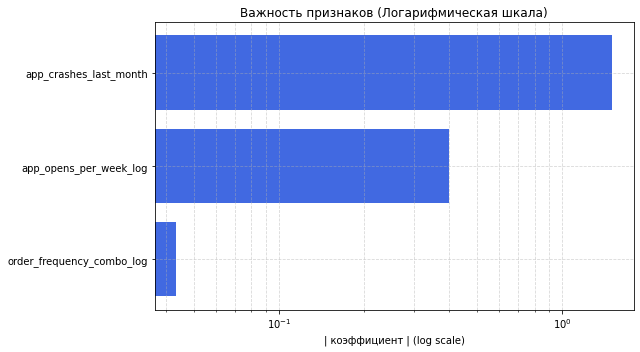

In [63]:
importance_filtered = importance[importance["abs_weight"] > 0]

plt.figure(figsize=(9, 5))

plt.barh(importance_filtered["feature"], importance_filtered["abs_weight"], color='royalblue')

# включаем логарифмическую шкалу для оси X
plt.xscale('log') 

plt.gca().invert_yaxis()
plt.title("Важность признаков (Логарифмическая шкала)")
plt.xlabel("| коэффициент | (log scale)")
plt.grid(True, which="both", ls="--", alpha=0.5) # добавим сетку 
plt.tight_layout()
plt.show()

#### Промежуточный вывод
Получена модель с почти целевой разделяющей способностью (0.7) и высокой точностью: PR_AUC 0.69, Precision 0.96. Теперь для неё можно подобрать порог. Её гиперпараметры:
```
{'clf__C': 0.01, 'clf__class_weight': None, 'clf__l1_ratio': 0.8, 'clf__penalty': 'elasticnet', 'clf__solver': 'saga'}
```
Её помогли получить замена коллинеарных переменных и логарифмирование, так же, отсев малозначимых шумных признаков.

По результатам подгонки модели подтвердились выводы о низкой разделяющей способности переменных. Их много, но разделяющая только одна: app_crashes_last_month_was_na, **app_crashes_last_month**.
Ещё несколько переменных можно разглядеть только при логорифмическом масштабе. Например: **app_opens_per_week_log**. И одна переменная с отрицательной корреляцией: **seasonal_menu_tried**.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


👉 Теперь подберём оптимальный порог на лучшей по PR_AUC (объясняющей TARGET) модели так, чтобы достич целевого **Precision 0.8** и максимизовать Recall. На данном шаге главная метрика Precision. Так как мы хотим минимизировать стоимость снижения оттока и не давать скидки и прочие плюшки всем подряд, а только тем, кто реально уйдёт, пусть и не всем 100%. Поэтому, Recall (охват) будет не максимальным, но зато точность максимальной.

In [64]:
best_model = grid.best_estimator_

# получаем вероятности ухода (класс 1) для тестового набора
y_test_probs = best_model.predict_proba(X_test)[:, 1]

# ищем оптимальный порог
TARGET_PRECISION = 0.80
best_th = 0.5
max_recall = 0
best_precision = 0
best_recall = 0

# итерируемся по порогам от 0.1 до 0.95 с шагом 0.01
for th in np.arange(0.1, 0.96, 0.01):
    y_pred_step = (y_test_probs >= th).astype(int)
    
    current_precision = precision_score(y_test, y_pred_step, zero_division=0)
    current_recall = recall_score(y_test, y_pred_step, zero_division=0)
    
    # точность устраивает бизнес, а полнота — максимальная из возможных
    if current_precision >= TARGET_PRECISION and current_recall > max_recall:
        max_recall = current_recall
        best_th = th
        best_precision, best_recall = current_precision, current_recall

print(f"Оптимальный порог: {best_th:.2f}, при этом precision = {best_precision:.2f}, recall = {best_recall:.2f}")

Оптимальный порог: 0.34, при этом precision = 0.81, recall = 0.57


✅ Оптимальный порог данной модели **0.34**, он даёт целевой Precision 0.81, при это охват оттока тоже неплохой: 57%.

In [86]:
final_test_preds = (y_test_probs >= best_th).astype(int)

final_precision = precision_score(y_test, final_test_preds, zero_division=0)
final_recall = recall_score(y_test, final_test_preds, zero_division=0)
final_f1 = f1_score(y_test, final_test_preds, zero_division=0)
final_f05 = fbeta_score(y_test, final_test_preds, beta=0.5, zero_division=0)
final_pr_auc = average_precision_score(y_test, y_test_probs)

y_train_probs = best_model.predict_proba(X_train)[:, 1]
final_train_preds = (y_train_probs >= best_th).astype(int)

final_precision_train = precision_score(y_train, final_train_preds, zero_division=0)
final_recall_train = recall_score(y_train, final_train_preds, zero_division=0)
final_f1_train = f1_score(y_train, final_train_preds, zero_division=0)
final_f05_train = fbeta_score(y_train, final_train_preds, beta=0.5, zero_division=0)
final_pr_auc_train = average_precision_score(y_train, y_train_probs)

# 3. Выводим красивую результирующую таблицу
test_metrics_df = pd.DataFrame({
    'Метрика': ['Порог (Threshold)', 'Precision', 'Recall', 'F1-score', 'F0.5-score', 'Pr Auc'],
    'Значение на Test Set': [
        f"{best_th:.2f}", 
        f"{final_precision:.4f}", 
        f"{final_recall:.4f}", 
        f"{final_f1:.4f}", 
        f"{final_f05:.4f}",
        f"{final_pr_auc:.4f}"],
    'Значение на Train Set': [
        f"{best_th:.2f}", 
        f"{final_precision_train:.4f}", 
        f"{final_recall_train:.4f}", 
        f"{final_f1_train:.4f}", 
        f"{final_f05_train:.4f}",
        f"{final_pr_auc_train:.4f}"]
})

print("\nИтоговые метрики:")
display(test_metrics_df)


Итоговые метрики:


,Метрика,Значение на Test Set,Значение на Train Set
0,Порог (Threshold),0.34,0.34
1,Precision,0.8118,0.7288
2,Recall,0.5750,0.5353
3,F1-score,0.6732,0.6172
4,F0.5-score,0.7500,0.6797
5,Pr Auc,0.7329,0.6930


## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

 ### Исследовательский анализ данных (EDA)

Анализ показал, что класс оттока (`churn = 1`) сильно несбалансирован и составляет всего **6%** от всех клиентов. Это делает метрику **PR-AUC** основной для оценки качества модели.

### Ключевые выводы по признакам

### Наиболее сильные индикаторы оттока

| Признак | Вывод |
|---------|-------|
| `app_crashes_last_month` | Клиенты, у которых приложение зависало, уходят в **3 раза чаще**. Это самый информативный признак. |
| `app_opens_per_week` | Уходящие клиенты открывают приложение чаще, что может указывать на попытки решения проблем или поиск альтернатив. |

#### Денежные показатели

Ушедшие клиенты тратили значительно больше (`total_spent_last_month`, `total_spent_last_week`) и чаще делали заказы (`order_frequency_week`, `order_frequency_month`). Активность выше.

#### `days_since_last_promo`:

У уходящих клиентов промо-акции использовались реже (медианный разрыв **10%**).

#### Категориальные признаки:

Такие признаки, как `preferred_roast`, `milk_preference`, `coffee_bean_origin` и `subscription_status`, показали некоторые различия в распределении по классам.

**Наиболее заметный отток наблюдается среди клиентов:**

| Характеристика | Значение |
|----------------|----------|
| Подписка | `'pro'` |
| Молоко | `'whole milk'` |
| Тип кофе | `'robusta'` |
| Регион | `'geo_2'`, `'geo_3'` |

---

### Обработка данных

В ходе анализа были обнаружены и исправлены проблемы, которые были учтены при построении финального пайплайна:

- Присутствовали **явные и неявные пропуски** (например, `'none'` в `subscription_status`)
- Обнаружена **высокая мультиколлинеарность** между `order_frequency_month` и `order_frequency_week`
- В данных были выявлены **выбросы** и **некорректные отрицательные значения**

---

### Вывод

Основные драйверы оттока связаны с **техническими проблемами в приложении**, а не с низкой активностью. Клиенты, которые сталкиваются с багами, уходят, несмотря на высокую лояльность и частоту заказов.

---

### 2. Подготовка данных и проектирование признаков

Для повышения качества модели были проведены следующие шаги:

#### Удаление шумовых признаков:

- Исключён `user_id` (бесполезен)
- Остальные признаки отсеивались по нулевым коэффициентам в пайплайне отдельным шагом.

#### Создание новых признаков:

Для снижения мультиколлинеарности и лучшего учета поведения клиентов были созданы новые признаки: order_frequency_combo', 'order_value_stability', 'weekly_spent_share'.

#### Обработка выбросов и пропусков:

- Применено **логарифмирование** для признаков с сильными выбросами.
- Применён **клиппинг по квантилям** 0.01, 0.99.
- Для категориальных признаков использовалось кодирование (`OneHotEncoder`, `TargetEncoder` для geo_id).

#### Стандартизация:

Числовые признаки были стандартизированы и нормализованы избирательно, с помощью StandardScaler, RobustScaler и MinMaxScaler.

---

Все этапы подготовки данных были объединены в единый трансформер (**Pipeline**), что обеспечивает воспроизводимость и готовность решения к работе в продакшене.

---

## 3. Обучение и выбор модели

Для решения задачи была выбрана **логистическая регрессия**.

| Аспект | Описание |
|--------|----------|
| **Выбор модели** | Логистическая регрессия является **интерпретируемой моделью**, что позволяет определить ключевые факторы, влияющие на отток. |
| **Подход к обучению** | Данные были разделены на обучающую и валидационную выборки. Для оценки качества использовалась **стратифицированная кросс-валидация**, чтобы учесть дисбаланс классов. |
| **Оценка качества** | Модель была обучена и оценена с использованием метрик **PR-AUC**, **F1-score**, **F05-score**, **Recall** и **Precision**. |

---

## 4. Итоговый вывод

Разработанный пайплайн и модель логистической регрессии позволяют с высокой вероятностью **73%** выявлять клиентов, которые планируют уйти в следующем месяце и с охватом **53%**. **Наиболее значимым фактором оттока является качество работы мобильного приложения**, а не ценовая политика или частота заказов.

---

### Рекомендации для бизнеса:


- Улучшить стабильность и производительность мобильного приложения для снижения числа сбоев.

- Использовать модель для сегментации клиентской базы. Выявленных "уходящих" клиентов можно вовлекать с помощью специальных предложений.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [77]:
class ChurnClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator, threshold=0.5):
        self.estimator = estimator
        self.threshold = threshold
        
    @property
    def classes_(self):
        return self.estimator.classes_
    
    def filt(self, X, y, **params):
        self.estimator.fit(X, y, **params)
        return self
    
    def predict_proba(self, X):
        check_is_fitted(self.estimator)
        return self.estimator.predict_proba(X)
    
    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]        
        return (probs >= self.threshold).astype(int)

### Сохранение пайплайна и метаданных модели

In [69]:
model_descriptor = {
    'pipeline': best_model,
    'optimal_threshold': best_th,
    'metrics_snapshot': {
        'precision': final_precision,
        'recall': final_recall,
        'pr_auc': final_pr_auc,
    }
}
files_list = joblib.dump(model_descriptor, 'logreg_churn_coffee_model.joblib', compress=3)
print('Модель сохранена:', files_list)

Модель сохранена: ['logreg_churn_coffee_model.joblib']


✅ Модель: https://k8s.jupyterhub.praktikum-services.ru/user/user-0-27358077/edit/logreg_churn_coffee_model.joblib

### Загрузка пайплайна

In [82]:
meta = joblib.load('logreg_churn_coffee_model.joblib')
clf = ChurnClassifier(meta['pipeline'], meta['optimal_threshold'])
predictions = clf.predict(X_test.sample(n=20, random_state=SEED))
print('Результат:', predictions)

Результат: [0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]


In [71]:
memory.clear(warn=False)
print("✅ Кэш препроцессинга очищен.")

✅ Кэш препроцессинга очищен.
